# PCLab#3 - Group 2 - Henricus Bracht Erdem Bayrakcioglu Leonard Fischbach

**Course:** 20598 - Finance with Big Data
**Lab:** PC Lab #3 - Creating a Factor from Text Data (Week 4)

We build a monthly stock factor from Stocktwits messages. The files overlap, and the `symbol` column is often the wrong ticker, so the stock comes from the cashtag in the text. There are no sentiment labels in the files. The main signal is abnormal attention, not sentiment. Expensive steps are cached under `cache/`.


### 0.1 Imports and setup


In [1]:
import html, logging, re, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk, numpy as np, pandas as pd, seaborn as sns, statsmodels.api as sm, torch
import yfinance as yf
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
for _pkg in ("wordnet", "omw-1.4", "stopwords"):
    nltk.download(_pkg, quiet=True)

LAB_DIR = Path.cwd() if (Path.cwd() / "UnlabelledDataset_2").exists() else Path.cwd() / "#3"
DATA_DIRS = [LAB_DIR / "UnlabelledDataset_2", LAB_DIR / "Data from 2010"]
CACHE_DIR = LAB_DIR / "cache"
CACHE_DIR.mkdir(exist_ok=True)

RANDOM_SEED, MARKET_TZ = 42, "America/New_York"
ATT_WINDOW_DAYS, ATT_BASELINE_WINDOWS = 30, 12
ATT_MIN_USERS, ATT_MIN_BASELINE, ATT_MIN_USABLE_FRAC = 5, 2.0, 0.60
BLACKOUT_START, BLACKOUT_END = pd.Timestamp("2017-09-01"), pd.Timestamp("2017-12-31")
FORMATION_START, FORMATION_END = "2014-01-01", "2020-06-30"
PRICE_START, PRICE_END = "2012-06-01", "2020-12-31"
N_PORTFOLIOS, N_PORTFOLIOS_WEEKLY = 10, 5
SAMPLE_CAP, SENTIMENT_MAX_LEN, SENTIMENT_BATCH = 200, 64, 256
SENTIMENT_SAMPLE_N = 200_000  # random messages for kappa / clouds (Task 3.2)
VOCAB_SAMPLE_N, WORDCLOUD_SAMPLE_N = 500_000, 150_000
ROBERTA_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"
FINBERT_ID = "ProsusAI/finbert"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "axes.titlesize": 11, "axes.labelsize": 10})
PALETTE = {"primary": "#1F4E79", "accent": "#C45911", "neutral": "#7F8C8D",
           "highlight": "#B03A2E", "focal": "#1A7A4C", "shade": "#E8EEF4",
           "positive": "#1A7A4C", "negative": "#B03A2E"}
TORCH_DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", TORCH_DEVICE)


Device: mps


## Task #1 — Data and descriptive statistics

### 1.1 Loading and cleaning

In [2]:
# Read every CSV, then drop duplicate message IDs.
raw_ids = []
for folder in DATA_DIRS:
    for path in sorted(folder.glob("stocktwits_*.csv")):
        part = pd.read_csv(path, usecols=["symbol", "message_id"],
                           dtype={"symbol": "string", "message_id": "int64"})
        part["src_file"] = path.name
        raw_ids.append(part)
raw_ids = pd.concat(raw_ids, ignore_index=True)
n_rows, n_ids = len(raw_ids), raw_ids["message_id"].nunique()
print(f"Rows read: {n_rows:,}")
print(f"Unique message IDs: {n_ids:,}")
print(f"Duplicate rows: {n_rows - n_ids:,}  ({(n_rows - n_ids) / n_rows:.1%})")
in_two = int((raw_ids.groupby("message_id")["src_file"].nunique() > 1).sum())
print(f"IDs that appear in more than one file: {in_two:,}")
del raw_ids

# Save in a parquet to avoid unnecessary computing when redoing
messages_path = CACHE_DIR / "messages.parquet"
if messages_path.exists():
    messages = pd.read_parquet(messages_path)
else:
    parts = []
    for folder in DATA_DIRS:
        for path in sorted(folder.glob("stocktwits_*.csv")):
            part = pd.read_csv(path, dtype={"symbol": "string", "message": "string",
                                            "user": "int64", "message_id": "int64"})
            part["src_file"] = path.name
            part["dt_utc"] = pd.to_datetime(part["datetime"], utc=True, format="ISO8601")
            part["dt_et"] = part["dt_utc"].dt.tz_convert(MARKET_TZ)
            parts.append(part.drop(columns="datetime"))
    messages = pd.concat(parts, ignore_index=True)
    messages = messages.drop_duplicates("message_id", keep="first")
    messages = messages.rename(columns={"symbol": "provided_symbol"})
    messages.to_parquet(messages_path, index=False)

messages = messages.drop_duplicates("message_id")

display(messages.head())
assert messages["message_id"].is_unique
assert messages[["message_id", "user", "dt_et"]].notna().all().all()
print(f"Messages kept: {len(messages):,}")


Rows read: 6,483,233
Unique message IDs: 5,564,920
Duplicate rows: 918,313  (14.2%)
IDs that appear in more than one file: 666,279


,message_id,message,dt_utc,dt_et,user,src_file,provided_symbol
0,229008387,Peak profit for the last 6 expired option aler...,2020-07-19 09:49:35+00:00,2020-07-19 05:49:35-04:00,1442893,stocktwits_AAPL.csv,AAPL
1,229008357,$AAPL [Jul-17 382.50 Calls] Option volume Up +...,2020-07-19 09:47:26+00:00,2020-07-19 05:47:26-04:00,1442893,stocktwits_AAPL.csv,AAPL
2,229007569,$TSLA the market will be in true bubble territ...,2020-07-19 09:01:25+00:00,2020-07-19 05:01:25-04:00,1115913,stocktwits_AAPL.csv,AAPL
3,229006733,$AAPL was analyzed by 26 analysts. The buy con...,2020-07-19 08:13:00+00:00,2020-07-19 04:13:00-04:00,47688,stocktwits_AAPL.csv,AAPL
4,229006403,$AAPL NEW ARTICLE : Dogs Of The Dow For August...,2020-07-19 07:54:05+00:00,2020-07-19 03:54:05-04:00,1555408,stocktwits_AAPL.csv,AAPL


Messages kept: 5,564,920


About one row in seven is a duplicate, mostly because the same message was saved in both folders. Two different people posting the same sentence are both kept. 
We converted the timestamps originally from UTC (Universal Coordinated Time, London winter) to Eastern Time (New York) because the stocks are listed at NYSE.

In [3]:
# A cashtag is $ plus 1-6 letters, optionally a dotted share class ($BRK.A).
CASHTAG_RE = re.compile(r"\$([A-Za-z]{1,6}(?:[.\-][A-Za-z])?)\b")
SHARE_CLASS = {"BRKA": "BRK.A", "BRKB": "BRK.B", "BFA": "BF.A", "BFB": "BF.B"}

def extract_cashtags(text):
    """Tickers written as $TICKER in the message. The symbol column is not used."""
    if not isinstance(text, str):
        return []
    found = []
    for raw in CASHTAG_RE.findall(text):
        ticker = raw.upper().replace("-", ".")
        found.append(SHARE_CLASS.get(ticker, ticker))
    return found



In [4]:
# Factor universe = scraped focal equities only (not the full S&P via co-mentions).
FOCAL_NON_EQUITY = {"SPY", "QQQ", "DIA", "VIX"}
FOCAL_FILES = [
    "AAPL", "AMZN", "NFLX", "QQQ", "TSLA", "ADBE", "BAC", "BRK.A", "BRK.B",
    "DIA", "DIS", "FB", "GOOG", "GOOGL", "HD", "INTC", "JNJ", "PG", "SPY",
    "T", "UNH", "V", "VIX", "VZ", "WMT",
]
RENAMES = {"FB": "META"}

# Canonical equity names for portfolios (FB → META); non-equities stay out.
_focal_equity_raw = [t for t in FOCAL_FILES if t not in FOCAL_NON_EQUITY]
rename_map = {old: new for old, new in RENAMES.items() if old in _focal_equity_raw}
universe = sorted({rename_map.get(t, t) for t in _focal_equity_raw})
members = set(universe)
focal_equities = list(universe)  # universe IS the scraped equities
NON_EQUITY = set(FOCAL_NON_EQUITY)  # kept if anything still references the name

print(f"Focal equities in the factor: {len(universe)}")
print("  " + ", ".join(universe))
print("Focal non-equities (descriptives only):", ", ".join(sorted(FOCAL_NON_EQUITY)))
print("Renames:", rename_map)


Focal equities in the factor: 21
  AAPL, ADBE, AMZN, BAC, BRK.A, BRK.B, DIS, GOOG, GOOGL, HD, INTC, JNJ, META, NFLX, PG, T, TSLA, UNH, V, VZ, WMT
Focal non-equities (descriptives only): DIA, QQQ, SPY, VIX
Renames: {'FB': 'META'}


These are the tickers that are used for the factor bnecause we only have data for tose 21 assets.

In [5]:
# Every cashtag in the corpus. The factor later keeps only focal equities.
# Paths for cached mention and message statistics files
mentions_path = CACHE_DIR / "mentions.parquet"
stats_path = CACHE_DIR / "message_stats.parquet"

if mentions_path.exists() and stats_path.exists():
    # Load cached data if it exists
    mentions = pd.read_parquet(mentions_path)
    message_stats = pd.read_parquet(stats_path)
else:
    # Extract cashtags from messages
    tags = messages["message"].map(extract_cashtags)
    # Keep only messages with at least one cashtag
    mentions = messages.loc[tags.str.len() > 0, ["message_id", "dt_et", "user"]].copy()
    mentions["ticker"] = tags.loc[mentions.index]
    # Each (message, ticker) pair is its own row
    mentions = mentions.explode("ticker")[["message_id", "ticker", "dt_et", "user"]]
    # Cache mentions to file for faster reloads
    mentions.to_parquet(mentions_path, index=False)
    # Word count statistics per message
    message_stats = messages[["message_id"]].copy()
    message_stats["n_words"] = messages["message"].str.split().str.len()
    # Cache message stats
    message_stats.to_parquet(stats_path, index=False)

mentions["ticker"] = mentions["ticker"].astype(str)  # ensure ticker as string
factor_mentions = mentions.copy()
# Rename tickers like FB→META
factor_mentions["ticker"] = factor_mentions["ticker"].replace(rename_map)
# Keep only mentions for which the ticker is in the focal universe
factor_mentions = factor_mentions.loc[factor_mentions["ticker"].isin(members)].reset_index(drop=True)

display(message_stats.head())
display(factor_mentions.head())


,message_id,n_chars,n_words,n_cashtags,has_url,has_emoji,has_html_entity
0,229008387,116,23,1,False,False,False
1,229008357,135,15,1,True,False,False
2,229007569,139,24,5,False,False,False
3,229006733,272,22,2,True,False,True
4,229006403,113,17,1,True,False,False


,message_id,ticker,dt_et,user
0,229008387,AAPL,2020-07-19 05:49:35-04:00,1442893
1,229008357,AAPL,2020-07-19 05:47:26-04:00,1442893
2,229007569,TSLA,2020-07-19 05:01:25-04:00,1115913
3,229007569,AMZN,2020-07-19 05:01:25-04:00,1115913
4,229007569,AAPL,2020-07-19 05:01:25-04:00,1115913


In [6]:
# Check contamination: file label vs actual cashtag mentions
from collections import Counter

CONTAMINATION_THRESHOLD = 0.40

# Prepare metadata with file label
meta = messages[["message_id", "src_file", "provided_symbol"]].copy()
spell = {"BRKA": "BRK.A", "BRKB": "BRK.B", "BFA": "BF.A", "BFB": "BF.B"}
own = {}
for src, symbols in meta.groupby("src_file")["provided_symbol"]:
    label = str(symbols.mode().iloc[0]).upper().replace("-", ".")
    own[src] = spell.get(label, label)
meta["own_ticker"] = meta["src_file"].map(own)

# Tag messages that contain their file's own ticker
tagged = mentions[["message_id", "ticker"]].merge(meta[["message_id", "own_ticker"]], on="message_id")
has_own = set(tagged.loc[tagged["ticker"] == tagged["own_ticker"], "message_id"])

rows = []
for src_file, g in meta.groupby("src_file", sort=True):
    ids = g["message_id"]
    miss = ~ids.isin(has_own)  # messages missing own ticker
    # Most common intruding ticker
    other = mentions.loc[mentions["message_id"].isin(ids[miss]) & (mentions["ticker"] != own[src_file]), "ticker"]
    modal = Counter(other).most_common(1)
    modal_t, modal_n = modal[0] if modal else ("-", 0)
    rows.append({
        "file_ticker": src_file.replace("stocktwits_", "").replace(".csv", ""),
        "rows": len(g),
        "share_missing_own": float(miss.mean()),
        "modal_intruder": modal_t,
        "intruder_share": modal_n / len(g)
    })

contamination = pd.DataFrame(rows).sort_values("share_missing_own", ascending=False)
n_blended = int((contamination["share_missing_own"] > CONTAMINATION_THRESHOLD).sum())

print(contamination.to_string(index=False))
print(f"\n{n_blended} of {len(contamination)} files are blends (>{CONTAMINATION_THRESHOLD:.0%} missing own cashtag).")


file_ticker    rows  share_missing_own modal_intruder  intruder_share
        JNJ   36004           0.681258              T        0.679091
        UNH   14316           0.592484              V        0.591995
      BRK.B   20309           0.547984            BAC        0.547491
        SPY  128471           0.507694            VIX        0.506052
        BAC  124471           0.404086           AMZN        0.403315
         FB   56029           0.212069            DIS        0.206929
       INTC    8453           0.178517             HD        0.177333
        WMT    6589           0.140841             VZ        0.138261
      GOOGL    7692           0.072543           GOOG        0.071633
        VIX   31819           0.002640            SPY        0.000943
          T   44048           0.002611            ATT        0.002089
        QQQ  541464           0.002597            SPY        0.002024
       AAPL 1221598           0.001568            SPY        0.000188
         VZ   35923 

Several CSVs are mixed: many rows lack the file’s own $TICKER and instead mention another name. We measure that share per src_file on the deduplicated corpus, so we use cashtags, not the filename or symbol column—for every stock in the lab.

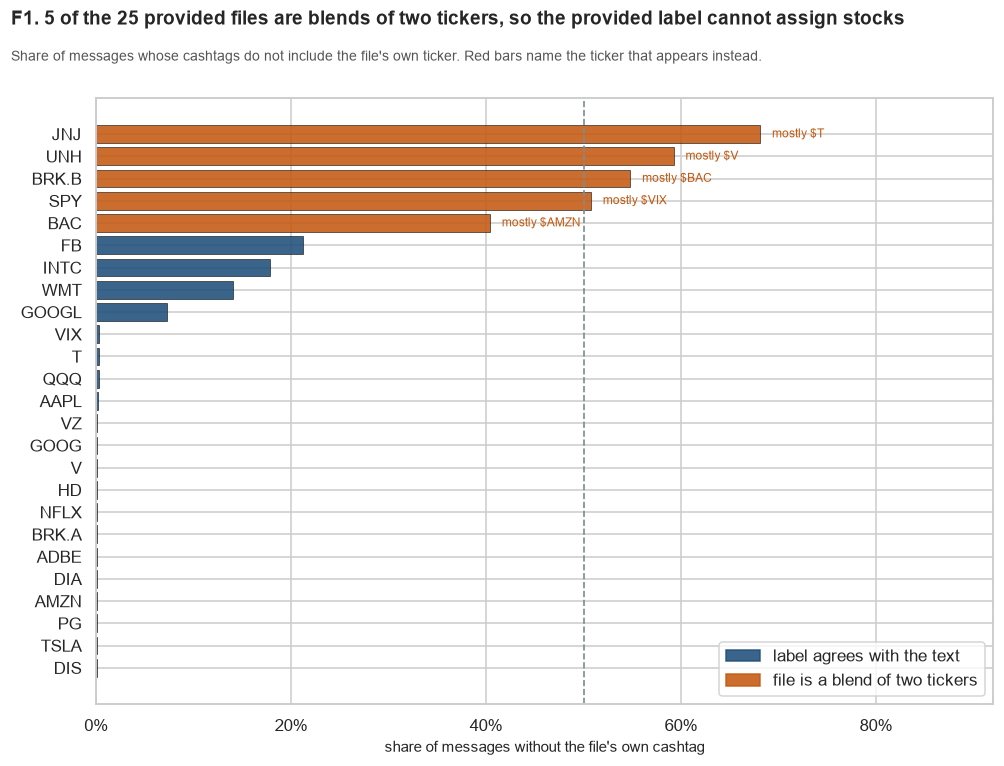

In [7]:
_c = contamination.sort_values("share_missing_own")
colors = np.where(_c["share_missing_own"] > CONTAMINATION_THRESHOLD, PALETTE["accent"], PALETTE["primary"])
fig, ax = plt.subplots(figsize=(9.2, 7.2))
ax.barh(_c["file_ticker"], _c["share_missing_own"], color=colors, edgecolor="black", linewidth=0.4, alpha=0.88)
ax.axvline(0.50, color=PALETTE["neutral"], linestyle="--", linewidth=1.1)
for y, (_, row) in enumerate(_c.iterrows()):
    if row["share_missing_own"] > CONTAMINATION_THRESHOLD:
        ax.text(row["share_missing_own"] + 0.012, y, f"mostly ${row['modal_intruder']}",
                va="center", fontsize=8, color=PALETTE["accent"])
ax.set_xlim(0, 0.92)
ax.set_xlabel("share of messages without the file's own cashtag")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=PALETTE["primary"], alpha=0.88, label="label agrees with the text"),
    plt.Rectangle((0, 0), 1, 1, color=PALETTE["accent"], alpha=0.88, label="file is a blend of two tickers"),
], loc="lower right")
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, f"F1. {n_blended} of the 25 provided files are blends of two tickers, so the provided label cannot assign stocks",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, "Share of messages whose cashtags do not include the file's own ticker. Red bars name the ticker that appears instead.",
         fontsize=9.2, color="#555555", ha="left", va="top")
plt.show()


Nine of the 25 files are blends. The file labelled JNJ is mostly T, and UNH is mostly V etc. The other files miss their own ticker on about one row in a hundred. From here on, every stock is taken from the cashtag.   
Using symbol column would have given a large block of attention to the wrong name.


### 1.2 Sample description


In [8]:
sample = messages.merge(message_stats, on="message_id", how="left")
words = sample["n_words"]
print("The sample")
print(f"  Messages (deduplicated)        : {len(sample):,}")
print(f"  Distinct posting accounts      : {sample['user'].nunique():,}")
print(f"  Cashtag mentions               : {len(mentions):,}")
print(f"  Distinct cashtag strings       : {mentions['ticker'].nunique():,}")
print(f"  First / last message (ET)      : {sample['dt_et'].min()} -> {sample['dt_et'].max()}")
print(f"  Words, mean / median / sd      : {words.mean():.2f} / {words.median():.0f} / {words.std():.2f}")
for q, v in words.quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).items():
    print(f"  p{int(q * 100):<2} words                    : {v:.0f}")
print(f"  Characters, mean / median      : {sample['n_chars'].mean():.1f} / {sample['n_chars'].median():.0f}")
print(f"  Share over 140 characters      : {(sample['n_chars'] > 140).mean():.1%}")
print(f"  Contain a URL                  : {sample['has_url'].mean():.1%}")
print(f"  Contain an HTML entity         : {sample['has_html_entity'].mean():.1%}")
print(f"  Contain an emoji               : {sample['has_emoji'].mean():.1%}")


The sample
  Messages (deduplicated)        : 5,564,920
  Distinct posting accounts      : 135,835
  Cashtag mentions               : 9,727,661
  Distinct cashtag strings       : 18,198
  First / last message (ET)      : 2009-07-10 17:47:36-04:00 -> 2020-07-23 21:15:39-04:00
  Words, mean / median / sd      : 15.26 / 13 / 12.58
  p1  words                    : 1
  p10 words                    : 4
  p25 words                    : 8
  p50 words                    : 13
  p75 words                    : 20
  p90 words                    : 26
  p99 words                    : 64
  Characters, mean / median      : 94.0 / 82
  Share over 140 characters      : 13.6%
  Contain a URL                  : 16.9%
  Contain an HTML entity         : 20.1%
  Contain an emoji               : 4.9%


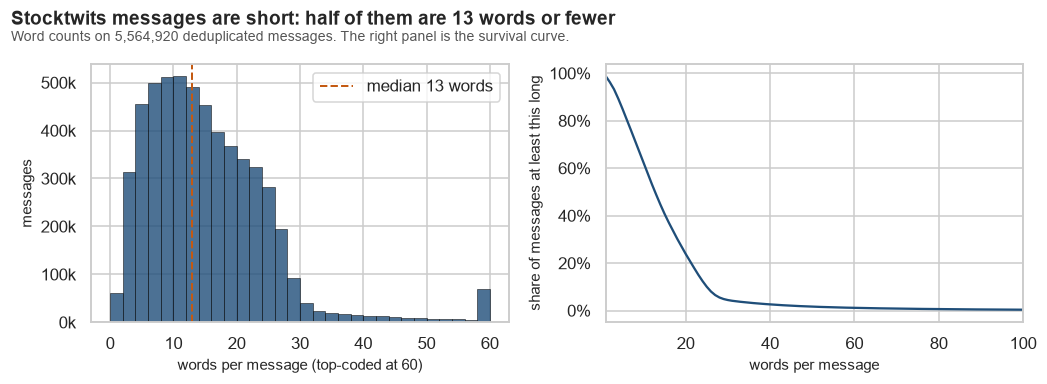

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
clipped = sample["n_words"].clip(upper=60)
axes[0].hist(clipped, bins=np.arange(0, 62, 2), color=PALETTE["primary"], edgecolor="black", linewidth=0.4, alpha=0.8)
axes[0].axvline(sample["n_words"].median(), color=PALETTE["accent"], linestyle="--", linewidth=1.3,
                label=f"median {sample['n_words'].median():.0f} words")
axes[0].set_xlabel("words per message (top-coded at 60)")
axes[0].set_ylabel("messages")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
axes[0].legend()
surv = sample["n_words"].value_counts(normalize=True).sort_index().cumsum()
axes[1].plot(surv.index, 1 - surv.values, color=PALETTE["primary"])
axes[1].set_xlim(1, 100)
axes[1].set_xlabel("words per message")
axes[1].set_ylabel("share of messages at least this long")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "Stocktwits messages are short: half of them are 13 words or fewer",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"Word counts on {len(sample):,} deduplicated messages. The right panel is the survival curve.",
         fontsize=9.2, color="#555555", ha="left", va="top")
plt.show()


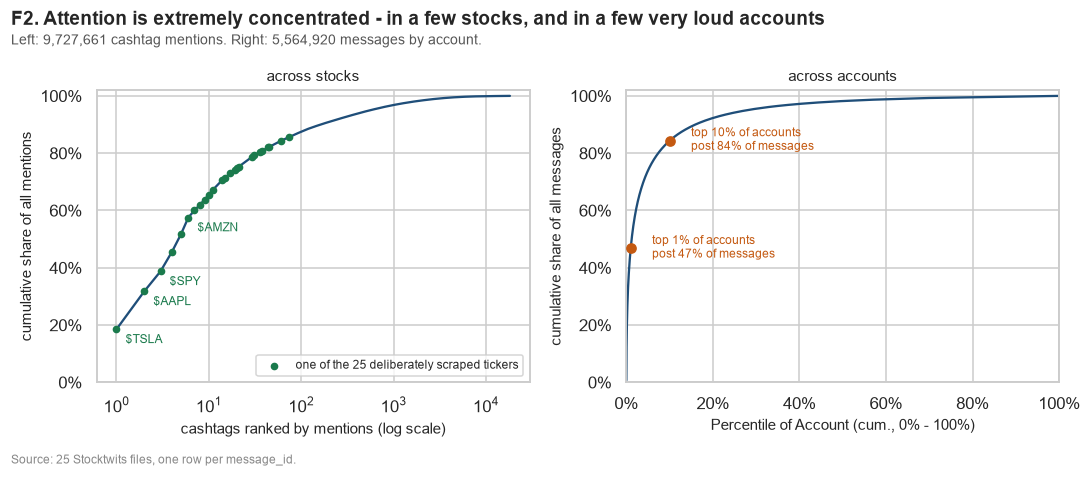

Top 10 cashtags: 65.5% of mentions
Top 25 cashtags: 77.0% of mentions
Top 1% of accounts: 46.7% of messages


In [10]:
tick_counts = mentions["ticker"].value_counts()
tick_share = tick_counts / tick_counts.sum()
tick_cum = tick_share.cumsum()
is_focal = tick_counts.index.isin(set(FOCAL_FILES))
user_counts = messages["user"].value_counts()
user_share = (user_counts / user_counts.sum()).cumsum()
user_pct = np.arange(1, len(user_counts) + 1) / len(user_counts)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
ax = axes[0]
ax.plot(np.arange(1, len(tick_cum) + 1), tick_cum.values, color=PALETTE["primary"])
ax.scatter(np.flatnonzero(is_focal) + 1, tick_cum.values[is_focal], s=16, color=PALETTE["focal"], zorder=3,
           label="one of the 25 deliberately scraped tickers")
for name in ["AAPL", "TSLA", "SPY", "AMZN"]:
    if name in tick_cum.index:
        r = tick_cum.index.get_loc(name) + 1
        ax.annotate(f"${name}", (r, tick_cum.iloc[r - 1]), fontsize=8, xytext=(6, -9),
                    textcoords="offset points", color=PALETTE["focal"])
ax.set_xscale("log")
ax.set_xlabel("cashtags ranked by mentions (log scale)")
ax.set_ylabel("cumulative share of all mentions")
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.legend(loc="lower right", fontsize=8)
ax.set_title("across stocks", fontsize=10)
ax = axes[1]
ax.plot(user_pct, user_share.values, color=PALETTE["primary"])
for p in (0.01, 0.10):
    idx = int(np.ceil(p * len(user_counts))) - 1
    ax.scatter([user_pct[idx]], [user_share.values[idx]], color=PALETTE["accent"], zorder=3)
    ax.annotate(f"top {p:.0%} of accounts\npost {user_share.values[idx]:.0%} of messages",
                (user_pct[idx], user_share.values[idx]), fontsize=8, xytext=(14, -6),
                textcoords="offset points", color=PALETTE["accent"])

ax.set_xlabel("Percentile of Account (cum., 0% - 100%)")
ax.set_ylabel("cumulative share of all messages")
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_title("across accounts", fontsize=10)

# Set x-axis as percentiles (0% 20% 40% ..., up to 100%)
percent_locs = np.linspace(0, 1, 6)  # 0%, 20%, ..., 100%
ax.set_xticks(percent_locs)
ax.set_xlim(0, 1.0)
ax.set_xticklabels([f"{int(p*100)}%" for p in percent_locs])

fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F2. Attention is extremely concentrated - in a few stocks, and in a few very loud accounts",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"Left: {len(mentions):,} cashtag mentions. Right: {len(messages):,} messages by account.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Source: 25 Stocktwits files, one row per message_id.", fontsize=7.6, color="#888888")
plt.show()
print(f"Top 10 cashtags: {tick_share.head(10).sum():.1%} of mentions")
print(f"Top 25 cashtags: {tick_share.head(25).sum():.1%} of mentions")
print(f"Top 1% of accounts: {user_share.iloc[int(0.01 * len(user_counts))]:.1%} of messages")


Attention is highly concentrated on both sides of the platform. A relatively small number of stocks accounts for a large share of all cashtag mentions, with the 25 focal stocks (green points) particularly prominent as they sit at the top of the distribution.  The right panel is why the factor counts users rather than messages: the top 1% of accounts write close to half of all messages, and the loudest accounts are bots. Each account counts once.


### 1.3 When people post

A message after the close should not enter that month's signal. The 2017 collection gap is handled with the factor, in section 4.1.


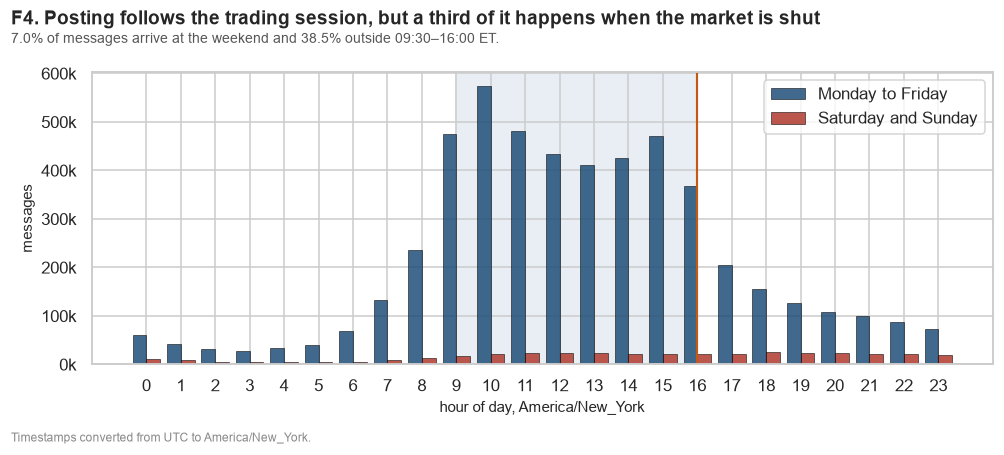

Share of messages at the weekend      : 7.0%
Share outside 09:30-16:00 New York    : 38.5%


In [11]:
hour = messages["dt_et"].dt.hour
weekend = messages["dt_et"].dt.dayofweek >= 5
by_hour = pd.crosstab(hour, weekend).rename(columns={False: "weekday", True: "weekend"})
share_weekend = float(weekend.mean())
share_off = float(((hour >= 16) | (hour < 9)).mean())
fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.bar(by_hour.index - 0.2, by_hour["weekday"], width=0.4, color=PALETTE["primary"],
       edgecolor="black", linewidth=0.4, alpha=0.85, label="Monday to Friday")
ax.bar(by_hour.index + 0.2, by_hour["weekend"], width=0.4, color=PALETTE["highlight"],
       edgecolor="black", linewidth=0.4, alpha=0.85, label="Saturday and Sunday")
ax.axvspan(9.0, 16, color=PALETTE["shade"], alpha=1, zorder=0)
ax.axvline(16, color=PALETTE["accent"], linewidth=1.4)
ax.set_xticks(range(0, 24))
ax.set_xlabel("hour of day, America/New_York")
ax.set_ylabel("messages")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
ax.legend()
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F4. Posting follows the trading session, but a third of it happens when the market is shut",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"{share_weekend:.1%} of messages arrive at the weekend and {share_off:.1%} outside 09:30–16:00 ET.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Timestamps converted from UTC to America/New_York.", fontsize=7.6, color="#888888")
plt.show()
print(f"Share of messages at the weekend      : {share_weekend:.1%}")
print(f"Share outside 09:30-16:00 New York    : {share_off:.1%}")


About 7% of messages arrive at the weekend, and a large share arrive outside 09:30–16:00 New York time. We therefore close each attention window at 16:00 on the last trading day of the month, not at midnight and not on the calendar date.


---

## Task #2 — Text cleaning

### 2.1 Cleaning

Lemmatising and dropping stopwords is what we want for a word count or a cloud, and it is the wrong input for a sentiment model: "not a bad quarter" and "a bad quarter" become the same tokens. The raw message is kept. Each model gets a light preprocessing. The clouds are in section 3.2, once we have labels.


In [12]:
import unicodedata
from collections import Counter

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
CASHTAG_TOKEN_RE = re.compile(r"\$[A-Za-z][A-Za-z.\-]*")
TICKER_NUM_RE = re.compile(r"\$\d[\d.,]*[KMB%]?", re.IGNORECASE)
ELONGATION_RE = re.compile(r"(\w)\1{2,}")
WORD_RE = re.compile(r"[a-z][a-z'\-]+")
EXTRA_STOPWORDS = {
    "rt", "amp", "stock", "stocks", "share", "shares", "market", "markets", "price",
    "trade", "trading", "trader", "traders", "today", "day", "week", "month", "year",
    "get", "got", "go", "going", "gon", "na", "one", "two", "like", "u", "im", "dont",
    "ha", "wa", "doe", "http", "https", "co", "com", "www", "via",
}
STOPWORDS = set(stopwords.words("english")) | EXTRA_STOPWORDS
_lemma, _cache = WordNetLemmatizer(), {}

def clean_text(text):
    """Tokens for word counts and clouds. Not the input we give a sentiment model."""
    if not text:
        return []
    t = html.unescape(text)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = TICKER_NUM_RE.sub(" ", t)
    t = CASHTAG_TOKEN_RE.sub(" ", t)
    t = unicodedata.normalize("NFKC", t).lower()
    t = ELONGATION_RE.sub(r"\1\1", t)
    tokens = []
    for word in WORD_RE.findall(t):
        if len(word) <= 2 or word in STOPWORDS:
            continue
        lemma = _cache.get(word)
        if lemma is None:
            lemma = _cache[word] = _lemma.lemmatize(word)
        tokens.append(lemma)
    return tokens


In [13]:
rng = np.random.default_rng(RANDOM_SEED)
pick = np.sort(rng.choice(len(messages), size=VOCAB_SAMPLE_N, replace=False))
vocab_sample = messages.iloc[pick][["message_id", "message"]].reset_index(drop=True)
print(f"Vocabulary sample: {len(vocab_sample):,} messages (seed {RANDOM_SEED}).")
probe = vocab_sample.merge(message_stats, on="message_id", how="left")
examples = [
    ("HTML entity", probe["has_html_entity"]),
    ("URL", probe["has_url"] & (probe["n_words"] > 12)),
    ("emoji, few words", probe["has_emoji"] & (probe["n_words"] <= 6)),
    ("several cashtags", probe["n_cashtags"] >= 3),
]
for label, mask in examples:
    hit = probe.loc[mask]
    if hit.empty:
        continue
    raw = hit.iloc[len(hit) // 2]["message"]
    print("=" * 80)
    print(f"[{label}]")
    print("  raw        :", " ".join(str(raw).split())[:180])
    print("  cleaned    :", " ".join(clean_text(raw))[:180])
    t = html.unescape(raw or "")
    roberta = re.sub(r"\s+", " ", MENTION_RE.sub("@user", URL_RE.sub("http", t))).strip()
    finbert = re.sub(r"\s+", " ", MENTION_RE.sub(" ", URL_RE.sub(" ", t))).strip()
    print("  roberta    :", roberta[:180])
    print("  finbert    :", finbert[:180])
    print("  vader      :", re.sub(r"\s+", " ", t).strip()[:180])


Vocabulary sample: 500,000 messages (seed 42).
[HTML entity]
  raw        : &quot;@TraderRL23: Weekly Recap: http://stks.co/f1vhC $SPX $SPY $COMPQ $QQQ $IWM&quot; Interesting data point on SPY outflows.
  cleaned    : weekly recap interesting data point spy outflow
  roberta    : "@user: Weekly Recap: http $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
  finbert    : " : Weekly Recap: $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
  vader      : "@TraderRL23: Weekly Recap: http://stks.co/f1vhC $SPX $SPY $COMPQ $QQQ $IWM" Interesting data point on SPY outflows.
[URL]
  raw        : Sell In May And Go Away: Is It The Best Move? http://stks.co/43mG $SPY $INDU $QQQ
  cleaned    : sell may away best move
  roberta    : Sell In May And Go Away: Is It The Best Move? http $SPY $INDU $QQQ
  finbert    : Sell In May And Go Away: Is It The Best Move? $SPY $INDU $QQQ
  vader      : Sell In May And Go Away: Is It The Best Move? http://stks.co/43mG $SPY $IND

The cleaned line is for the vocabulary and the clouds. A bot alert shrinks to a few words. Emoji-only messages stay in for RoBERTa, FinBERT and VADER and disappear in the cleaned text.


### 2.2 Vocabulary


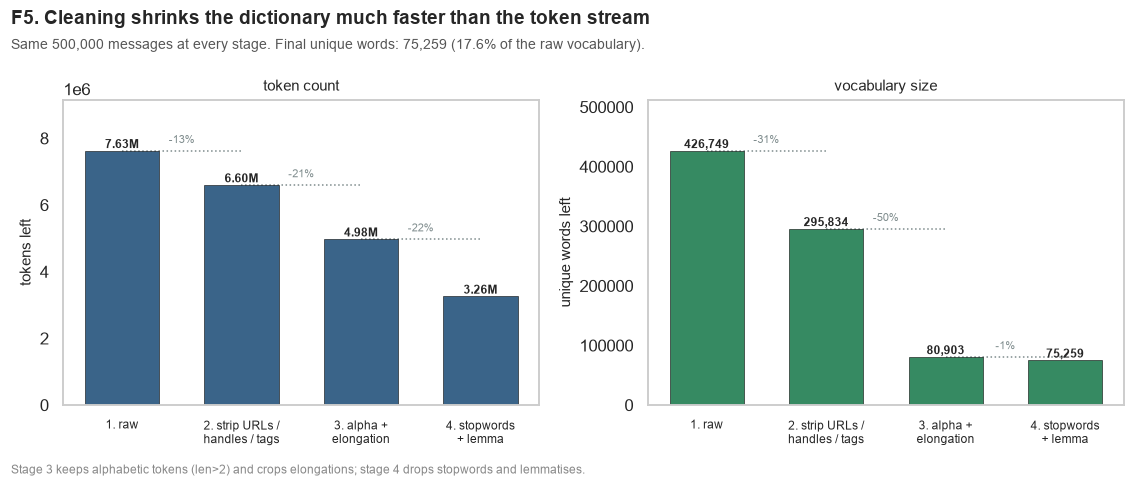

Final unique words: 75,259  (17.6% of raw vocabulary)


In [14]:
# How many tokens and words survive each cleaning step, on the same 500,000 messages.
texts = vocab_sample["message"].tolist()
stages = []

raw_tokens, raw_types = 0, Counter()
for text in texts:
    words = text.lower().split() if isinstance(text, str) else []
    raw_tokens += len(words)
    raw_types.update(words)
stages.append(("1. raw whitespace tokens", raw_tokens, len(raw_types)))

stripped_tokens, stripped_types = 0, Counter()
for text in texts:
    if not isinstance(text, str) or not text:
        words = []
    else:
        s = CASHTAG_TOKEN_RE.sub(" ", TICKER_NUM_RE.sub(" ", MENTION_RE.sub(" ", URL_RE.sub(" ", html.unescape(text)))))
        words = s.lower().split()
    stripped_tokens += len(words)
    stripped_types.update(words)
stages.append(("2. drop URLs, handles, prices, cashtags", stripped_tokens, len(stripped_types)))

alpha_tokens, alpha_types = 0, Counter()
for text in texts:
    if not isinstance(text, str) or not text:
        words = []
    else:
        s = CASHTAG_TOKEN_RE.sub(" ", TICKER_NUM_RE.sub(" ", MENTION_RE.sub(" ", URL_RE.sub(" ", html.unescape(text)))))
        s = ELONGATION_RE.sub(r"\1\1", unicodedata.normalize("NFKC", s).lower())
        words = [w for w in WORD_RE.findall(s) if len(w) > 2]
    alpha_tokens += len(words)
    alpha_types.update(words)
stages.append(("3. alphabetic tokens, elongation cropped", alpha_tokens, len(alpha_types)))

clean_tokens, clean_types = 0, Counter()
for text in texts:
    words = clean_text(text)
    clean_tokens += len(words)
    clean_types.update(words)
stages.append(("4. drop stopwords and lemmatise", clean_tokens, len(clean_types)))

waterfall = pd.DataFrame(stages, columns=["stage", "tokens", "vocabulary"])
base_tok = int(waterfall.loc[0, "tokens"])
base_voc = int(waterfall.loc[0, "vocabulary"])
final_vocab = int(waterfall["vocabulary"].iloc[-1])
waterfall["tokens_left"] = waterfall["tokens"] / base_tok
waterfall["vocabulary_left"] = waterfall["vocabulary"] / base_voc
waterfall["label"] = [
    "1. raw",
    "2. strip URLs /\nhandles / tags",
    "3. alpha +\nelongation",
    "4. stopwords\n+ lemma",
]

def _plot_waterfall(ax, values, color, ylabel):
    values = np.asarray(values, float)
    x = np.arange(len(values))
    ax.bar(x, values, width=0.62, color=color, edgecolor="black", linewidth=0.4, alpha=0.88, zorder=2)
    for i in range(1, len(values)):
        drop = values[i - 1] - values[i]
        if drop > 0:
            ax.plot([i - 1, i], [values[i - 1], values[i - 1]],
                    color=PALETTE["neutral"], linewidth=1.0, linestyle=":", zorder=1)
            ax.annotate(
                f"-{drop / values[0]:.0%}",
                xy=(i - 0.5, values[i - 1]),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=7.5, color=PALETTE["neutral"],
            )
    for i, v in enumerate(values):
        label = f"{v / 1e6:.2f}M" if v >= 1e6 else f"{v:,.0f}"
        ax.text(i, v, label, ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(waterfall["label"], fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, values[0] * 1.20)
    ax.grid(False)  # Remove gridlines

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3))
_plot_waterfall(axes[0], waterfall["tokens"], PALETTE["primary"], "tokens left")
_plot_waterfall(
    axes[1], waterfall["vocabulary"], PALETTE["focal"], "unique words left",
)
axes[0].set_title("token count", fontsize=10)
axes[1].set_title("vocabulary size", fontsize=10)
fig.tight_layout(rect=(0, 0.02, 1, 0.88))
fig.text(0.01, 0.985, "F5. Cleaning shrinks the dictionary much faster than the token stream",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(
    0.01, 0.925,
    f"Same {VOCAB_SAMPLE_N:,} messages at every stage. Final unique words: {final_vocab:,} "
    f"({final_vocab / base_voc:.1%} of the raw vocabulary).",
    fontsize=9.2, color="#555555", ha="left", va="top",
)
fig.text(0.01, 0.005,
         "Stage 3 keeps alphabetic tokens (len>2) and crops elongations; stage 4 drops stopwords and lemmatises.",
         fontsize=7.6, color="#888888")
plt.show()
print(f"Final unique words: {final_vocab:,}  ({final_vocab / base_voc:.1%} of raw vocabulary)")


In [15]:
top = pd.DataFrame(clean_types.most_common(15), columns=["term", "count"])
top["share"] = top["count"] / clean_tokens
print(top.to_string(index=False))
counts = np.sort(np.fromiter(clean_types.values(), dtype=int))[::-1]
print(f"Terms that appear once: {(counts == 1).sum():,}  ({(counts == 1).mean():.1%} of the vocabulary), not used for training")


 term  count    share
short  28292 0.008674
  buy  24093 0.007386
 call  20129 0.006171
  see  18279 0.005604
 time  18262 0.005599
tesla  16591 0.005086
 good  16383 0.005023
  put  16123 0.004943
 back  16077 0.004929
  new  15827 0.004852
 long  15188 0.004656
 next  14975 0.004591
 bear  14219 0.004359
 look  13870 0.004252
still  12997 0.003985
Terms that appear once: 40,960  (54.4% of the vocabulary), not used for training


Most of the vocabulary that disappears is numeric junk from bots: prices, strikes, timestamps. Each of those strings appears once, so the dictionary shrinks much faster than the number of tokens. What remains at the top of the list is trading language (`buy`, `short`, `call`, `long`), not news about the firm.


---

## Task #3 — Sentiment analysis

### 3.1 Model comparison

The files contain no sentiment labels, so we cannot report accuracy on this corpus. We compare Twitter-RoBERTa, FinBERT and VADER on SemEval-2017 Task 5, a set of financial microblogs scored from −1 to +1. For the transformers the prediction is `s = p_pos − p_neg`. We keep the model with the highest cosine similarity. VADER is the lexicon baseline. Vader is a rule based / dictionary based approach to do sentiment analysis, every word has a polarization value (negation e.g. or reinforcing (e.g. "very"), caps, emojis). No neural net just a heuristic

![Darth Vader](https://upload.wikimedia.org/wikipedia/en/0/0b/Darth_Vader_in_The_Empire_Strikes_Back.jpg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original)





In [16]:
# SemEval-2017 Task 5: financial microblogs with a score from -1 to +1. Not our files.
import hashlib
import json
import urllib.request

SEMEVAL_COMMIT = "beadeb1fd0f9b8093e4828a198a92e651a4e10c6"
SEMEVAL_BASE = (
    "https://bitbucket.org/ssix-project/semeval-2017-task-5-subtask-1/"
    f"raw/{SEMEVAL_COMMIT}"
)
SEMEVAL_FILES = {
    "Microblog_Trainingdata.json":
        "45dadef6b3f6b9b36f84923c28e3ddee4a5253f1a8b163d2fe7e3fec5037c43f",
    "Microblog_Trialdata.json": None,
}

def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def ensure_semeval_raw():
    """Download SSIX SemEval JSONs into cache/semeval/ if missing."""
    raw_dir = CACHE_DIR / "semeval"
    raw_dir.mkdir(parents=True, exist_ok=True)
    for name, expected in SEMEVAL_FILES.items():
        dest = raw_dir / name
        if not dest.exists():
            print(f"Downloading SemEval file: {name}")
            urllib.request.urlretrieve(f"{SEMEVAL_BASE}/{name}", dest)
        if expected is not None:
            got = _sha256(dest)
            if got != expected:
                raise ValueError(
                    f"{name} checksum mismatch:\n  expected {expected}\n  got {got}")
    return raw_dir

def build_semeval_benchmark():
    raw_dir = ensure_semeval_raw()
    rows = []
    for name in SEMEVAL_FILES:
        for rec in json.loads((raw_dir / name).read_text()):
            if "sentiment score" not in rec:
                continue
            spans = rec.get("spans", [])
            text = " ".join(spans) if isinstance(spans, list) else str(spans)
            tag = str(rec.get("cashtag") or "")
            rows.append({
                "bench_id": str(rec.get("id")),
                "cashtag": tag,
                "gold": float(rec["sentiment score"]),
                "text": text if tag.upper() in text.upper() else f"{tag} {text}".strip(),
            })
    out = pd.DataFrame(rows).drop_duplicates(["bench_id", "cashtag"])
    out["multi_cashtag"] = out.groupby("bench_id")["cashtag"].transform("nunique") > 1
    return out

# Always ensure the raw SemEval JSONs exist; rebuild the tidy table if needed.
ensure_semeval_raw()
bench_path = CACHE_DIR / "benchmark.parquet"
if bench_path.exists():
    benchmark = pd.read_parquet(bench_path)
else:
    benchmark = build_semeval_benchmark()
    benchmark.to_parquet(bench_path, index=False)

print(f"Benchmark messages: {len(benchmark):,}")
print(f"Gold score, mean / sd: {benchmark['gold'].mean():+.3f} / {benchmark['gold'].std():.3f}")
print("No labelled file was provided with the Stocktwits CSVs.")


Benchmark messages: 1,699
Gold score, mean / sd: +0.117 / 0.380
No labelled file was provided with the Stocktwits CSVs.


1,699 benchmark messages: Semeval-2017 financial microblogs with gold scores in [−1, +1], not your StockTwits CSVs. That’s the hold-out used to compare RoBERTa, FinBERT, and VADER.

Gold mean +0.117 / sd 0.380: Labels lean slightly bullish on average, but with wide spread (lots near zero). Models need nuance, not just a “all positive” call.

No labelled StockTwits file: Your corpus has no sentiment labels, so you can’t report accuracy there. Pick the best model on SemEval, then score StockTwits with it.


In [17]:
def score_sentiment(texts, model):
    """s = P(positive) - P(negative). VADER uses its compound score instead."""
    texts = ["" if t is None else str(t) for t in texts]
    if model == "vader":
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        vader = SentimentIntensityAnalyzer()
        scores, labels = [], []
        for text in texts:
            s = vader.polarity_scores(html.unescape(text))["compound"]
            label = "positive" if s >= 0.05 else "negative" if s <= -0.05 else "neutral"
            scores.append(s)
            labels.append(label)
        return pd.DataFrame({"score": scores, "label": labels, "bypassed": False})

    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    model_id = ROBERTA_ID if model == "roberta" else FINBERT_ID
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    network = AutoModelForSequenceClassification.from_pretrained(model_id).to(TORCH_DEVICE).eval()
    names = {int(k): v.lower() for k, v in network.config.id2label.items()}
    col = {name: i for i, name in names.items()}
    cleaned = []
    for text in texts:
        text = html.unescape(text)
        if model == "roberta":
            text = MENTION_RE.sub("@user", URL_RE.sub("http", text))
        else:
            text = MENTION_RE.sub(" ", URL_RE.sub(" ", text))
        cleaned.append(re.sub(r"\s+", " ", text).strip() or " ")
    scores, labels = [], []
    for start in range(0, len(cleaned), SENTIMENT_BATCH):
        batch = cleaned[start:start + SENTIMENT_BATCH]
        enc = tokenizer(batch, truncation=True, max_length=SENTIMENT_MAX_LEN, padding=True, return_tensors="pt")
        enc = {k: v.to(TORCH_DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            prob = torch.softmax(network(**enc).logits, dim=-1).cpu().numpy()
        p_neg, p_neu, p_pos = prob[:, col["negative"]], prob[:, col["neutral"]], prob[:, col["positive"]]
        scores.append(p_pos - p_neg)
        labels.append(np.array(["negative", "neutral", "positive"])[np.argmax(np.c_[p_neg, p_neu, p_pos], 1)])
    return pd.DataFrame({"score": np.concatenate(scores), "label": np.concatenate(labels), "bypassed": False})


In [18]:
from scipy import stats
bench_rows, bench_detail = [], {}
for model in ("roberta", "finbert", "vader"):
    pred = score_sentiment(benchmark["text"], model)
    gold = benchmark["gold"].to_numpy()
    score = pred["score"].to_numpy()
    keep = np.isfinite(score) & np.isfinite(gold)
    g, p = gold[keep], score[keep]

    point = float(np.dot(g, p) / (np.linalg.norm(g) * np.linalg.norm(p)))
    rng = np.random.default_rng(RANDOM_SEED)
    cos_draws, rho_draws = [], []
    for _ in range(1000):
        ix = rng.integers(0, len(g), len(g))
        cos_draws.append(float(np.dot(g[ix], p[ix]) / (np.linalg.norm(g[ix]) * np.linalg.norm(p[ix]))))
        rho_draws.append(float(stats.spearmanr(g[ix], p[ix]).correlation))
    bench_rows.append({
        "model": model, "n": int(keep.sum()),
        "cosine": point, "cosine_lo": np.percentile(cos_draws, 2.5), "cosine_hi": np.percentile(cos_draws, 97.5),
        "spearman": float(stats.spearmanr(g, p).correlation),
        "spearman_lo": np.percentile(rho_draws, 2.5), "spearman_hi": np.percentile(rho_draws, 97.5),
        "mae": float(np.mean(np.abs(g - p))), "rmse": float(np.sqrt(np.mean((g - p) ** 2))),
    })
    bench_detail[model] = p
    print(f"{model:8}  cosine {bench_rows[-1]['cosine']:.4f}   Spearman {bench_rows[-1]['spearman']:.4f}")
bench_metrics = pd.DataFrame(bench_rows).sort_values("cosine", ascending=False)
PRIMARY_MODEL = bench_metrics.iloc[0]["model"]
if PRIMARY_MODEL == "vader":
    PRIMARY_MODEL = "roberta"
print("\nPrimary model:", PRIMARY_MODEL)
print(bench_metrics.round(4).to_string(index=False))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


roberta   cosine 0.6471   Spearman 0.5688


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

finbert   cosine 0.4875   Spearman 0.4553
vader     cosine 0.3430   Spearman 0.2815

Primary model: roberta
  model    n  cosine  cosine_lo  cosine_hi  spearman  spearman_lo  spearman_hi    mae   rmse
roberta 1699  0.6471     0.6190     0.6752    0.5688       0.5347       0.6009 0.3594 0.4404
finbert 1699  0.4875     0.4548     0.5230    0.4553       0.4162       0.4918 0.3654 0.4394
  vader 1699  0.3430     0.3064     0.3827    0.2815       0.2397       0.3255 0.3424 0.4130


Twitter-RoBERTa is ahead of FinBERT and VADER on the benchmark. These scores are on the 2017 labelled microblogs, not on our 5.56 million messages. Annotators agreed with each other at a Spearman of about 0.69, which is a rough ceiling. We do not compare the numbers with the published leaderboard, which used a weighted cosine.

**Cosine (c. 0.65 / 0.49 / 0.34)**: Alignment of predicted vs gold score vectors (SemEval-style). Higher is better. lo/hi are bootstrap 95% bands; RoBERTa and FinBERT barely overlap, so the gap is stable.  
**Spearman (c. 0.57 / 0.46 / 0.28)**: Rank correlation: do bullish/bearish orderings match? Again RoBERTa leads; c. 0.57 sits under the c. 0.69 annotator ceiling.  
**MAE / RMSE**: Absolute error on the −1…+1 scale. All three look similar (MAE c. 0.34–0.37); VADER can even look slightly better here but fails on direction/ranking. You pick by cosine/Spearman, not by smallest absolute error.


### 3.2 Sentiment in our messages, and the word clouds

No labels on StockTwits, so we take a random sample of messages, score them with all three models, and report Cohen's kappa (agreement, not accuracy) plus word clouds / log-odds for the primary model. Cleaning for the clouds is the same pipeline as Task #2.


In [19]:
# Take random unique messages, cache sample
sample_path = CACHE_DIR / "sentiment_sample_random.parquet"
text_path = CACHE_DIR / "sentiment_sample_text_random.parquet"
if sample_path.exists() and text_path.exists():
    sample_text = pd.read_parquet(text_path).drop_duplicates("message_id")
else:
    ids = factor_mentions["message_id"].drop_duplicates()
    if len(ids) > SENTIMENT_SAMPLE_N:
        ids = ids.sample(SENTIMENT_SAMPLE_N, random_state=RANDOM_SEED)
    sample_text = messages.loc[messages["message_id"].isin(ids), ["message_id", "message"]].drop_duplicates("message_id")
    sample_text.to_parquet(text_path, index=False)
    sample_text[["message_id"]].to_parquet(sample_path, index=False)
print(f"Distinct messages to score: {len(sample_text):,}")


Distinct messages to score: 200,000


In [20]:
# Score the sample once per model; reuse the parquet if it already exists.
sentiment_scores = {}
for model in ("roberta", "finbert", "vader"):
    path = CACHE_DIR / f"scores_{model}_random.parquet"
    if path.exists():
        sentiment_scores[model] = pd.read_parquet(path)
    else:
        scored = score_sentiment(sample_text["message"].tolist(), model)
        scored.insert(0, "message_id", sample_text["message_id"].to_numpy())
        scored.to_parquet(path, index=False)
        sentiment_scores[model] = scored
    print(f"{model}: {len(sentiment_scores[model]):,} rows")


roberta: 200,000 rows
finbert: 200,000 rows
vader: 200,000 rows


In [21]:
from sklearn.metrics import cohen_kappa_score
labels = {model: frame.drop_duplicates("message_id").set_index("message_id")["label"]
          for model, frame in sentiment_scores.items()}
rows = []
keys = list(labels)
for i, a in enumerate(keys):
    for b in keys[i + 1:]:
        both = pd.concat([labels[a].rename("a"), labels[b].rename("b")], axis=1).dropna()
        rows.append({"model_a": a, "model_b": b, "n": len(both),
                     "cohen_kappa": float(cohen_kappa_score(both["a"], both["b"]))})
agree = pd.DataFrame(rows)


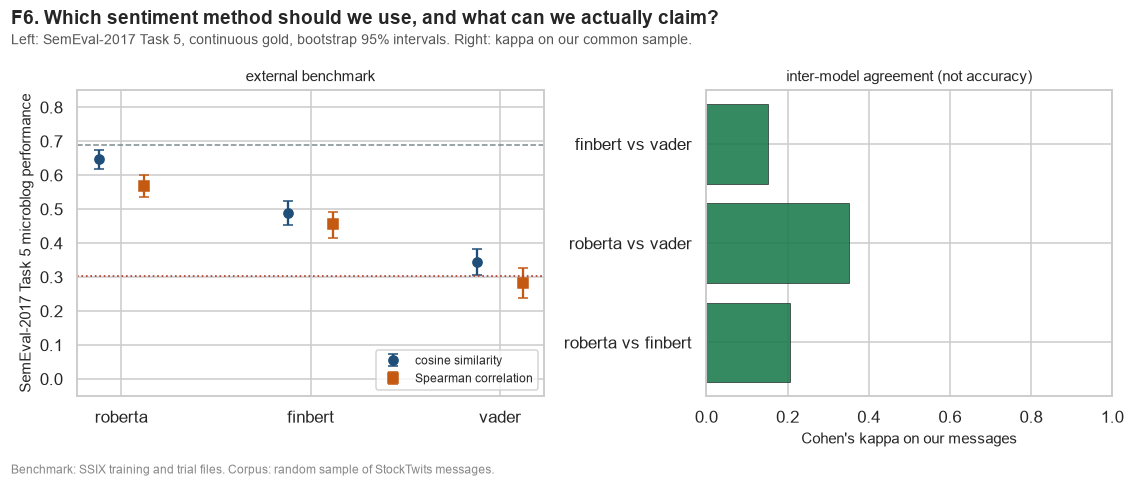

In [22]:
SEMEVAL_SPEARMAN_CEILING, SEMEVAL_SENTIWORDNET = 0.69, 0.3021
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
order = bench_metrics.sort_values("cosine", ascending=False)
x = np.arange(len(order))
ax.errorbar(x - 0.12, order["cosine"],
            yerr=np.vstack([order["cosine"] - order["cosine_lo"], order["cosine_hi"] - order["cosine"]]),
            fmt="o", color=PALETTE["primary"], capsize=3, label="cosine similarity")
ax.errorbar(x + 0.12, order["spearman"],
            yerr=np.vstack([order["spearman"] - order["spearman_lo"], order["spearman_hi"] - order["spearman"]]),
            fmt="s", color=PALETTE["accent"], capsize=3, label="Spearman correlation")
ax.axhline(SEMEVAL_SPEARMAN_CEILING, color=PALETTE["neutral"], linestyle="--", linewidth=1.0)
ax.axhline(SEMEVAL_SENTIWORDNET, color=PALETTE["highlight"], linestyle=":", linewidth=1.1)
ax.set_xticks(x)
ax.set_xticklabels(order["model"])
ax.set_ylim(-0.05, 0.85)
ax.set_ylabel("SemEval-2017 Task 5 microblog performance")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("external benchmark", fontsize=10)
ax = axes[1]
ax.barh(agree["model_a"] + " vs " + agree["model_b"], agree["cohen_kappa"],
        color=PALETTE["focal"], edgecolor="black", linewidth=0.4, alpha=0.88)
ax.set_xlim(0, 1)
ax.set_xlabel("Cohen's kappa on our messages")
ax.set_title("inter-model agreement (not accuracy)", fontsize=10)
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F6. Which sentiment method should we use, and what can we actually claim?",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, "Left: SemEval-2017 Task 5, continuous gold, bootstrap 95% intervals. Right: kappa on our common sample.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Benchmark: SSIX training and trial files. Corpus: random sample of StockTwits messages.",
         fontsize=7.6, color="#888888")
plt.show()


Left visualizes the SemEval benchmark as explained above.  
On our messages, on the right, the models barely agree (kappa c.0.15–0.35). That is not accuracy, only “same label?”. So even the best SemEval model is a erratic labeler on StockTwits.  
Use RoBERTa if you need a tone score; do not treat sentiment as a clean trading signal. Attention stays the main factor for us, not sentiment.

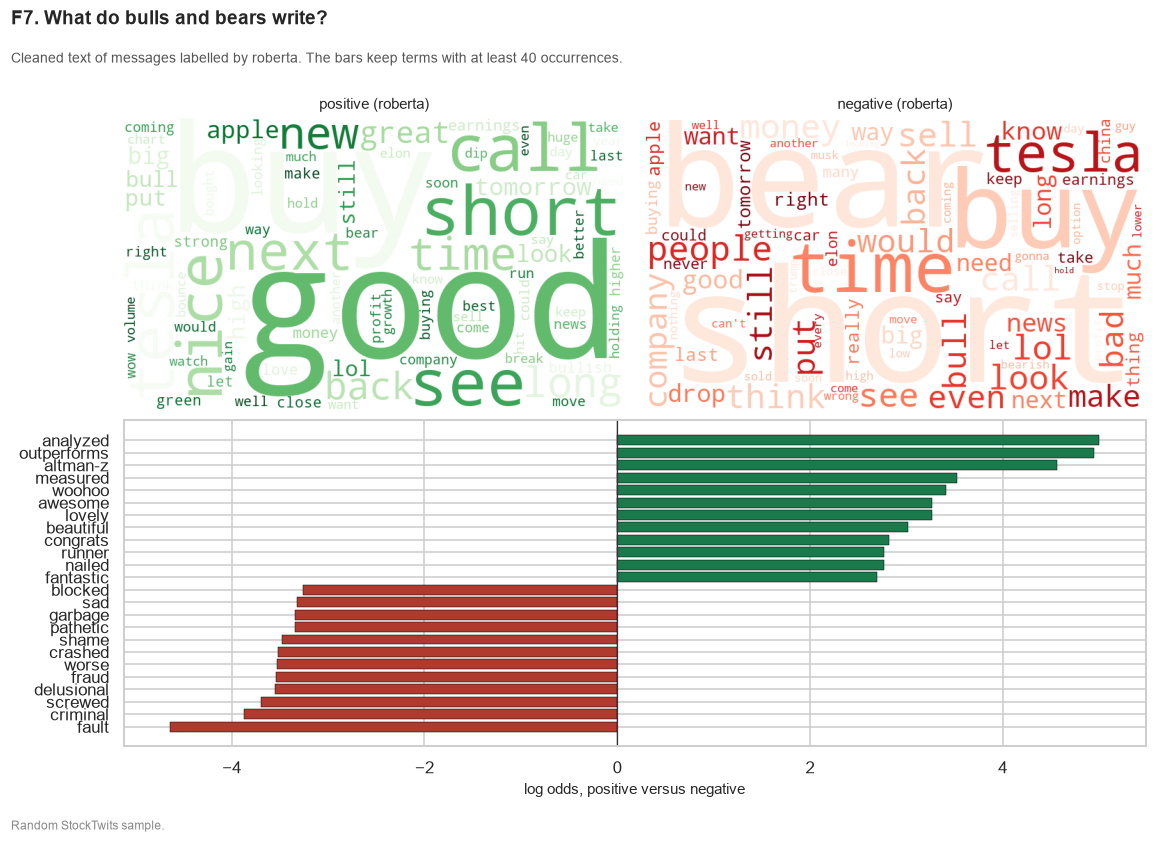

In [23]:
from collections import Counter
from wordcloud import WordCloud
cloud = sentiment_scores[PRIMARY_MODEL].drop_duplicates("message_id").merge(sample_text, on="message_id")
pos_txt = cloud.loc[cloud["label"] == "positive", "message"]
neg_txt = cloud.loc[cloud["label"] == "negative", "message"]
if len(pos_txt) > WORDCLOUD_SAMPLE_N:
    pos_txt = pos_txt.sample(WORDCLOUD_SAMPLE_N, random_state=RANDOM_SEED)
if len(neg_txt) > WORDCLOUD_SAMPLE_N:
    neg_txt = neg_txt.sample(WORDCLOUD_SAMPLE_N, random_state=RANDOM_SEED)
pos_counter, neg_counter = Counter(), Counter()
for text in pos_txt.dropna():
    pos_counter.update(clean_text(text))
for text in neg_txt.dropna():
    neg_counter.update(clean_text(text))
pos_n, neg_n = sum(pos_counter.values()), sum(neg_counter.values())
odds = []
for word in set(pos_counter) | set(neg_counter):
    cp, cn = pos_counter[word], neg_counter[word]
    if cp + cn < 40:
        continue
    odds.append((word, np.log(((cp + 0.5) / (pos_n + 1)) / ((cn + 0.5) / (neg_n + 1)))))
odds = pd.DataFrame(odds, columns=["term", "log_odds"])
show = pd.concat([odds.nlargest(12, "log_odds"), odds.nsmallest(12, "log_odds")]).sort_values("log_odds")
wc_pos = WordCloud(width=720, height=420, background_color="white", colormap="Greens",
                   max_words=80, random_state=RANDOM_SEED).generate_from_frequencies(pos_counter)
wc_neg = WordCloud(width=720, height=420, background_color="white", colormap="Reds",
                   max_words=80, random_state=RANDOM_SEED).generate_from_frequencies(neg_counter)
fig = plt.figure(figsize=(10.6, 7.6))
ax1, ax2, ax3 = fig.add_subplot(2, 2, 1), fig.add_subplot(2, 2, 2), fig.add_subplot(2, 1, 2)
ax1.imshow(wc_pos); ax1.set_axis_off(); ax1.set_title(f"positive ({PRIMARY_MODEL})", fontsize=10)
ax2.imshow(wc_neg); ax2.set_axis_off(); ax2.set_title(f"negative ({PRIMARY_MODEL})", fontsize=10)
ax3.barh(show["term"], show["log_odds"], color=np.where(show["log_odds"] > 0, PALETTE["positive"], PALETTE["negative"]),
         edgecolor="black", linewidth=0.3)
ax3.axvline(0, color="#333333", linewidth=0.8)
ax3.set_xlabel("log odds, positive versus negative")
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F7. What do bulls and bears write?", fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"Cleaned text of messages labelled by {PRIMARY_MODEL}. The bars keep terms with at least 40 occurrences.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Random StockTwits sample.", fontsize=7.6, color="#888888")
plt.show()


Clouds: Both sides are trading slang (buy, long/short, call, earnings) — not news language. Words like buy/good show up in both, so raw frequency barely separates RoBERTa’s labels.

Log-odds: What marks “positive” is mostly screener/bot jargon (altman-z, piotroski, f-score, chartmill). What marks “negative” is anger and insults (disgusting, corrupt, moron, jail).

Takeaway: StockTwits sentiment is trader chatter plus spam, not clean fundamentals — same story as Task #2, and why attention stays the main factor

---

## Task #4 — Media attention and returns

### 4.1 Measuring attention

We measure attention as the number of distinct users posting about a stock in the 30 days up to the month-end close. We drop sentiment from the factor. The files have no labels; on our messages the models disagree (low kappa); the text is trading slang and screener spam rather than clean polarity.  
$g^{ATT}_{i,t}$ measures abnormal user coverage, not tone. Mixing the two would blur the signal. Attention stays the sorting variable; sentiment is only diagnostic in Task #3. To account for the fact that some stocks are always more discussed than others, we subtract that stock's own attention over the previous 360 days.

$$
g^{ATT}_{i,t} = \log(1 + U_i(W_t)) - \log(1 + U^{base}_{i,t}), \qquad
U^{base}_{i,t} = U_i(B_t \cap D) \times 30 / |B_t \cap D|
$$

- $i$: stock; $t$: formation time (month-end close, 16:00 ET)
- $W_t$: the 30-day window just before $t$
- $U_i(W_t)$: number of distinct users posting about $i$ in that window
- $B_t$: baseline span — the previous ~360 days (12 × 30)
- $D$: usable days in the baseline (2017 blackout days removed)
- $U_i(B_t \cap D)$: distinct users in that usable baseline history
- $U^{base}_{i,t}$: that baseline count scaled to a **30-day rate**
- $g^{ATT}_{i,t}$: abnormal attention = log window minus log baseline

The factor $\times 30 / |B_t \cap D|$ puts the long baseline on the same footing as the 30-day window. Raw counts are not comparable (e.g. 80 users in 30 days vs 400 in 360). Scaling by $30 / |B \cap D|$ turns the baseline into an equivalent "users per 30 days," so the subtraction is fair. The 30 is simply the length of our attention window.

A stock-month needs at least 5 users in the window and a baseline of at least 2. Message counts collapse for four months in late 2017, and the drop differs by ticker, so those months are dropped rather than rescaled. The same days are removed from the baseline, so a hole in the history is not mistaken for a jump in attention. Portfolios are ten equal-weighted groups, held from that close to the next one.


In [24]:
# Prices on the focal equities + SPY calendar; month-end / week-end closes at 16:00 ET.
price_path = CACHE_DIR / "prices.parquet"
if price_path.exists():
    prices = pd.read_parquet(price_path)
else:
    # Download Yahoo Finance close prices for all tickers in universe + SPY
    symbols = sorted({t.replace(".", "-") for t in universe} | {"SPY"})
    raw = yf.download(symbols, start=PRICE_START, end=PRICE_END, auto_adjust=True, progress=False, threads=True)
    close = raw["Close"].dropna(axis=1, how="all").sort_index()
    prices = close.stack().rename("close").reset_index()
    prices.columns = ["date", "yahoo_ticker", "close"]
    prices["ticker"] = prices["yahoo_ticker"].str.replace("-", ".", regex=False)
    prices = prices[["date", "ticker", "close"]]
    prices.to_parquet(price_path, index=False)

# Extract trading days for SPY
trading_days = pd.DatetimeIndex(sorted(prices.loc[prices["ticker"] == "SPY", "date"].unique()))
# Restrict to formation window
window = trading_days[(trading_days >= FORMATION_START) & (trading_days <= FORMATION_END)]
# Find month-end and week-end dates in window (formation period)
month_ends = window.to_series().groupby([window.year, window.month]).max()
formation_monthly = (pd.DatetimeIndex(month_ends).normalize() + pd.Timedelta(hours=16)).tz_localize(MARKET_TZ)
iso = window.isocalendar()
week_ends = window.to_series().groupby([iso["year"].to_numpy(), iso["week"].to_numpy()]).max()
formation_weekly = (pd.DatetimeIndex(week_ends).normalize() + pd.Timedelta(hours=16)).tz_localize(MARKET_TZ)
# Pivot prices for easy access (date x ticker)
price_wide = prices.pivot_table(index="date", columns="ticker", values="close").sort_index()

print(f"Price rows: {len(prices):,}   tickers: {prices['ticker'].nunique()}")
print(f"Monthly formation dates: {len(formation_monthly)}   weekly: {len(formation_weekly)}")


Price rows: 47,520   tickers: 22
Monthly formation dates: 78   weekly: 340


In [25]:
def calculate_abnormal_attention(mentions, formation_ts, window_days=30, n_baseline=12,
                                 min_users=5, min_baseline=2.0, min_usable=0.60,
                                 count="users", gap_aware=True):
    """
    Compute 'abnormal attention' for each stock and formation timestamp.
    
    For each formation_ts (e.g., month-end), compares number of distinct users/messages
    in a recent window vs. a long-term baseline, corrected for 2017 blackout.
    """
    # Pre-sort mentions for fast slicing
    m = mentions.sort_values("dt_et", kind="stable", ignore_index=True)
    ts = m["dt_et"].values.astype("datetime64[ns]").astype("int64")
    ticker, mid = m["ticker"].to_numpy(), m["message_id"].to_numpy()
    # What is counted - users or message IDs
    unit = m["user"].to_numpy() if count == "users" else mid
    # Blackout mask for 2017 message collapse
    in_blackout = ((m["dt_et"].dt.tz_localize(None).dt.normalize() >= BLACKOUT_START)
                   & (m["dt_et"].dt.tz_localize(None).dt.normalize() <= BLACKOUT_END)).to_numpy()
    day_ns = 86_400_000_000_000  # nanoseconds in one day
    base_days = window_days * n_baseline  # total days in baseline
    panels = []  # Output container

    for t in pd.DatetimeIndex(formation_ts):
        t_ns = int(t.value)
        # Window: (t-window, t], Baseline: history before window
        w0, b0 = t_ns - window_days * day_ns, t_ns - window_days * day_ns - base_days * day_ns
        lo_w, hi_w = np.searchsorted(ts, [w0, t_ns], side="right")
        lo_b, hi_b = np.searchsorted(ts, [b0, w0], side="right")

        # Attention in the window (recent activity)
        w = pd.DataFrame({"ticker": ticker[lo_w:hi_w], "u": unit[lo_w:hi_w]})
        n_w = w.groupby("ticker", observed=True).size()  # total counts
        u_w = w.drop_duplicates().groupby("ticker", observed=True).size() if count == "users" else n_w

        # Baseline attention (historic activity)
        b = pd.DataFrame({"ticker": ticker[lo_b:hi_b], "u": unit[lo_b:hi_b]})
        if gap_aware and len(b):
            b = b.loc[~in_blackout[lo_b:hi_b]]  # Mask blackout dates
        if len(b) == 0:
            u_b = pd.Series(dtype="int64")
        elif count == "users":
            u_b = b.drop_duplicates().groupby("ticker", observed=True).size()
        else:
            u_b = b.groupby("ticker", observed=True).size()

        # Baseline window calculation / blackout handling
        t_day = t.tz_localize(None).normalize()
        b_end = t_day - pd.Timedelta(days=window_days)
        b_start = b_end - pd.Timedelta(days=base_days - 1)
        if gap_aware and b_start <= BLACKOUT_END and b_end >= BLACKOUT_START:
            # Number of blackout days that fall inside baseline period
            blackout_days = (min(b_end, BLACKOUT_END) - max(b_start, BLACKOUT_START)).days + 1
        else:
            blackout_days = 0
        usable = base_days - blackout_days  # Adjust baseline length for 2017 gap

        # Compose output frame
        frame = pd.concat([u_w.rename("att_window"), n_w.rename("n_window"), u_b.rename("raw_base")], axis=1).fillna(0.0)
        frame = frame.loc[frame["att_window"] > 0].copy()
        # Scale baseline to per-window_days basis
        frame["att_baseline"] = frame["raw_base"] * window_days / max(usable, 1)
        # Form eligibility mask (enough users/messages, baseline quality, doesn't touch the blackout)
        touches = not (t_day - pd.Timedelta(days=window_days - 1) > BLACKOUT_END or t_day < BLACKOUT_START)
        frame["eligible"] = ((frame["att_window"] >= min_users) & (frame["att_baseline"] >= min_baseline)
                             & (usable / base_days >= min_usable) & (not touches))
        frame["formation_ts"] = t
        panels.append(frame.reset_index())

    out = pd.concat(panels, ignore_index=True)
    out["ticker"] = out["ticker"].astype(str)
    return out


In [26]:
# Attention in the previous 30 days, versus the stock's own previous 360 days.
signal_path = CACHE_DIR / "g_att_monthly.parquet"
if signal_path.exists():
    signal = pd.read_parquet(signal_path)
    signal["formation_ts"] = pd.to_datetime(signal["formation_ts"], utc=True).dt.tz_convert(MARKET_TZ)
else:
    signal = calculate_abnormal_attention(
        factor_mentions, formation_monthly,
        window_days=ATT_WINDOW_DAYS, n_baseline=ATT_BASELINE_WINDOWS,
        min_users=ATT_MIN_USERS, min_baseline=ATT_MIN_BASELINE, min_usable=ATT_MIN_USABLE_FRAC)
    signal.to_parquet(signal_path, index=False)

# Abnormal attention
signal["g_att"] = np.log1p(signal["att_window"]) - np.log1p(signal["att_baseline"])
signal["ticker"] = signal["ticker"].astype(str)
assert signal["g_att"].notna().all()
eligible = signal.loc[signal["eligible"]].copy()
print(f"Eligible stock-months: {len(eligible):,}")
print(f"Formation dates kept: {eligible['formation_ts'].nunique()} of {len(formation_monthly)}")
print(f"Median names per date: {eligible.groupby('formation_ts').size().median():.1f}")


Eligible stock-months: 11,606
Formation dates kept: 74 of 78
Median names per date: 149.5


Worst five tickers, blackout / previous six months: $TSLA=0.16, $BRK.A=0.18, $NFLX=0.20, $AMZN=0.20, $AAPL=0.21
Least affected: $JNJ=0.58, $UNH=0.62, $PG=0.78, $T=0.80, $INTC=0.90


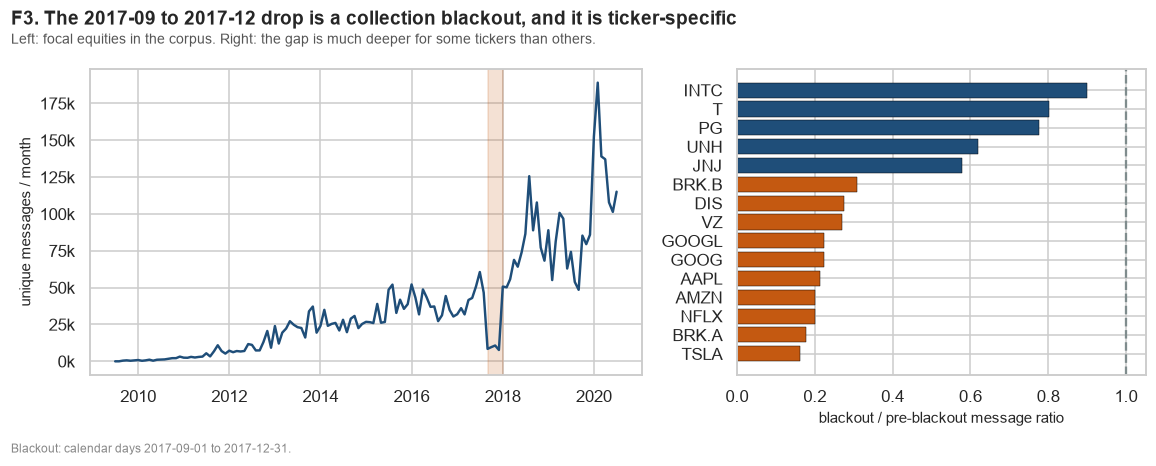

Dates kept: 74 of 78
Eligible stock-months: 11,606
Median names per date: 149.5   (14.9 per decile)


In [27]:
# The four month-end windows that touch Sep–Dec 2017 are dropped, not rescaled.
month = factor_mentions["dt_et"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
monthly = factor_mentions.drop_duplicates("message_id").groupby(month).size()
pre = (month >= "2017-03-01") & (month <= "2017-08-01")
gap = (month >= "2017-09-01") & (month <= "2017-12-01")
pre_n = factor_mentions.loc[pre].groupby("ticker")["message_id"].nunique() / 6
gap_n = factor_mentions.loc[gap].groupby("ticker")["message_id"].nunique() / 4
ratio = (gap_n / pre_n.replace(0, np.nan)).dropna()
ratio = ratio.loc[pre_n.reindex(ratio.index) >= 50].sort_values()
print("Worst five tickers, blackout / previous six months:",
      ", ".join(f"${t}={ratio[t]:.2f}" for t in ratio.head(5).index))
print("Least affected:", ", ".join(f"${t}={ratio[t]:.2f}" for t in ratio.tail(5).index))
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.1), gridspec_kw={"width_ratios": [1.35, 1]})
axes[0].plot(monthly.index, monthly.values, color=PALETTE["primary"], linewidth=1.6)
axes[0].axvspan(pd.Timestamp("2017-09-01"), pd.Timestamp("2018-01-01"), color=PALETTE["accent"], alpha=0.18)
axes[0].set_ylabel("unique messages / month")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:.0f}k"))
show = pd.concat([ratio.head(10), ratio.tail(5)])
axes[1].barh(show.index.astype(str), show.values,
             color=np.where(show.values < 0.5, PALETTE["accent"], PALETTE["primary"]),
             edgecolor="black", linewidth=0.3)
axes[1].axvline(1.0, color=PALETTE["neutral"], linestyle="--")
axes[1].set_xlabel("blackout / pre-blackout message ratio")
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F3. The 2017-09 to 2017-12 drop is a collection blackout, and it is ticker-specific",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, "Left: focal equities in the corpus. Right: the gap is much deeper for some tickers than others.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Blackout: calendar days 2017-09-01 to 2017-12-31.", fontsize=7.6, color="#888888")
plt.show()
per_date = eligible.groupby("formation_ts").size()
print(f"Dates kept: {eligible['formation_ts'].nunique()} of {len(formation_monthly)}")
print(f"Eligible stock-months: {len(eligible):,}")
print(f"Median names per date: {per_date.median():.1f}   ({per_date.median() / N_PORTFOLIOS:.1f} per decile)")


The right-hand panel of F3 is the point: the gap is much deeper for some tickers than for others, so it is a collection problem.


### 4.2 Raw versus abnormal attention

Raw unique-user counts favour names that are always loud. Abnormal attention compares each stock with its own past first. The factor panel is the scraped focal equities only.


Focal equities ranked: 11,606
Spearman(raw-level decile, g^ATT decile): +0.38
Mean abnormal g by decile:
portfolio
1     -0.316
2     +0.009
3     +0.186
4     +0.316
5     +0.434
6     +0.547
7     +0.662
8     +0.789
9     +0.958
10    +1.317


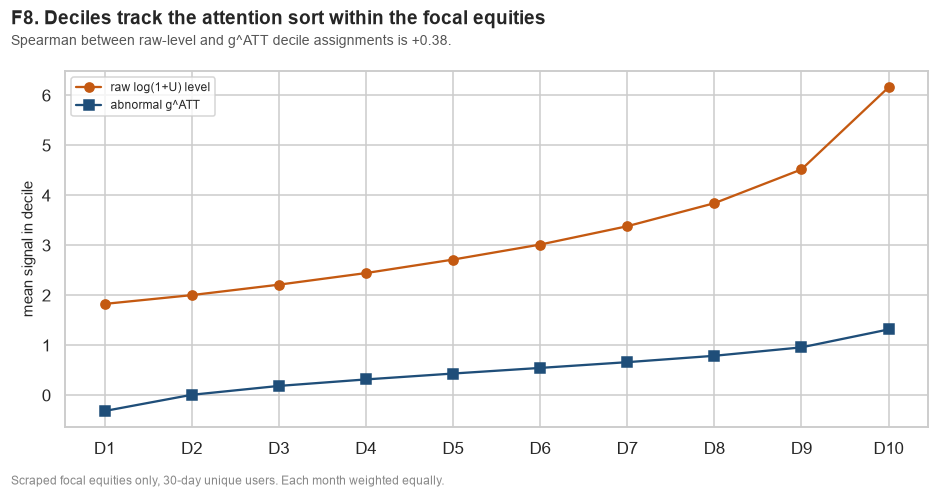

In [28]:
def assign_deciles(df, signal_col, n=10):
    """Ten equal-count portfolios inside each formation date. 1 = lowest signal."""
    out = df.copy()
    ranks = out.groupby("formation_ts", observed=True)[signal_col].rank(method="first", ascending=True)
    sizes = out.groupby("formation_ts", observed=True)[signal_col].transform("size")
    out["portfolio"] = np.ceil(ranks / sizes * n).astype(int).clip(1, n)
    return out

level = eligible.copy()
level["level"] = np.log1p(level["att_window"])
raw_assigned = assign_deciles(level, "level")
abn_assigned = assign_deciles(eligible, "g_att")

rank_cmp = (
    abn_assigned[["formation_ts", "ticker", "portfolio"]]
    .merge(raw_assigned[["formation_ts", "ticker", "portfolio"]],
           on=["formation_ts", "ticker"], suffixes=("_g", "_level"))
)
rho_rank = float(stats.spearmanr(rank_cmp["portfolio_g"], rank_cmp["portfolio_level"]).correlation)
mean_g = abn_assigned.groupby("portfolio", observed=True)["g_att"].mean()
mean_level = raw_assigned.groupby("portfolio", observed=True)["level"].mean()

print(f"Focal equities ranked: {len(abn_assigned):,}")
print(f"Spearman(raw-level decile, g^ATT decile): {rho_rank:+.2f}")
print("Mean abnormal g by decile:")
print(mean_g.map(lambda x: f"{x:+.3f}").to_string())

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(mean_level.index, mean_level.values, marker="o", color=PALETTE["accent"],
        label="raw log(1+U) level")
ax.plot(mean_g.index, mean_g.values, marker="s", color=PALETTE["primary"],
        label="abnormal g^ATT")
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"D{i}" for i in range(1, 11)])
ax.set_ylabel("mean signal in decile")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F8. Deciles track the attention sort within the focal equities",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935,
         f"Spearman between raw-level and g^ATT decile assignments is {rho_rank:+.2f}.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Scraped focal equities only, 30-day unique users. Each month weighted equally.",
         fontsize=7.6, color="#888888")
plt.show()

# Aliases for the abstract cell
rho_level = rho_abn = rho_rank
d10_focal_level = d10_focal_abn = 1.0


Within the scraped focal equities, abnormal attention still reorders names relative to the raw unique-user level (see Spearman in F7). There is no outside-S&P co-mention panel: every name in the sort is one of the files we were given.


### 4.3 Ten portfolios

The return is the adjusted close at one formation date to the adjusted close at the next. Subtracting the T-bill rate does not change D10−D1, because every stock in a month loses the same rate.


In [42]:
def calculate_portfolio_returns(panel, return_col):
    """Equal-weighted portfolio return on each formation date."""
    grouped = panel.groupby(["formation_ts", "portfolio"], observed=True)[return_col]
    out = grouped.agg(ret="mean", n="size", sd="std").reset_index()
    out["se"] = out["sd"] / np.sqrt(out["n"])
    return out

# Rank into ten portfolios
portfolios = assign_deciles(eligible, "g_att", N_PORTFOLIOS)
portfolios["form_date"] = portfolios["formation_ts"].dt.tz_localize(None).dt.normalize()

# Next-month returns: close on this formation date to the close on the next one.
form_dates = pd.DatetimeIndex(sorted(portfolios["form_date"].unique()))
px = price_wide.reindex(form_dates)
next_month = px.pct_change().shift(-1)
long = next_month.stack().rename("raw_return").reset_index()
long.columns = ["form_date", "ticker", "raw_return"]
long["ticker"] = long["ticker"].astype(str)
port_panel = portfolios.merge(long, on=["form_date", "ticker"], how="inner")
port_panel = port_panel.loc[np.isfinite(port_panel["raw_return"])].copy()

# Average return per portfolio
monthly = calculate_portfolio_returns(port_panel, "raw_return")
wide = monthly.pivot(index="formation_ts", columns="portfolio", values="ret")
spread = (wide[N_PORTFOLIOS] - wide[1]).dropna()
decile_mean = wide.mean()
decile_se = wide.std(ddof=1) / np.sqrt(wide.count())
print(f"Stock-months with a next-month return: {len(port_panel):,}   months: {spread.shape[0]}")
print("Mean next-month return by decile:")
print(decile_mean.map(lambda v: f"{v:.2%}").to_string())
print(f"D10-D1: {spread.mean():+.4%} per month")


Stock-months with a next-month return: 1,456   months: 48
Mean next-month return by decile:
portfolio
1     2.06%
2     0.36%
3     0.40%
4     3.03%
5     1.58%
6     1.97%
7     1.65%
8     2.12%
9     2.00%
10    1.35%
D10-D1: -0.9726% per month


In [43]:
hac_rows = []
y = spread.to_numpy()
for lag in (0, 3, 6, 12):
    fit = sm.OLS(y, np.ones((len(y), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": lag, "use_correction": True})
    hac_rows.append({"hac_lags": lag, "mean": float(fit.params[0]), "se": float(fit.bse[0]),
                     "t_stat": float(fit.tvalues[0]), "p_value": float(fit.pvalues[0]),
                     "n_periods": len(y)})
spread_table = pd.DataFrame(hac_rows)
spread_hac_t = float(spread_table.loc[spread_table["hac_lags"] == 3, "t_stat"].iloc[0])
sharpe = float(spread.mean() / spread.std(ddof=1) * np.sqrt(12))
print(spread_table.round(4).to_string(index=False))
print(f"Annualised Sharpe of the monthly spread: {sharpe:.2f}")


 hac_lags    mean     se  t_stat  p_value  n_periods
        0 -0.0097 0.0091 -1.0673   0.2858         48
        3 -0.0097 0.0069 -1.4051   0.1600         48
        6 -0.0097 0.0068 -1.4202   0.1555         48
       12 -0.0097 0.0055 -1.7710   0.0766         48
Annualised Sharpe of the monthly spread: -0.53


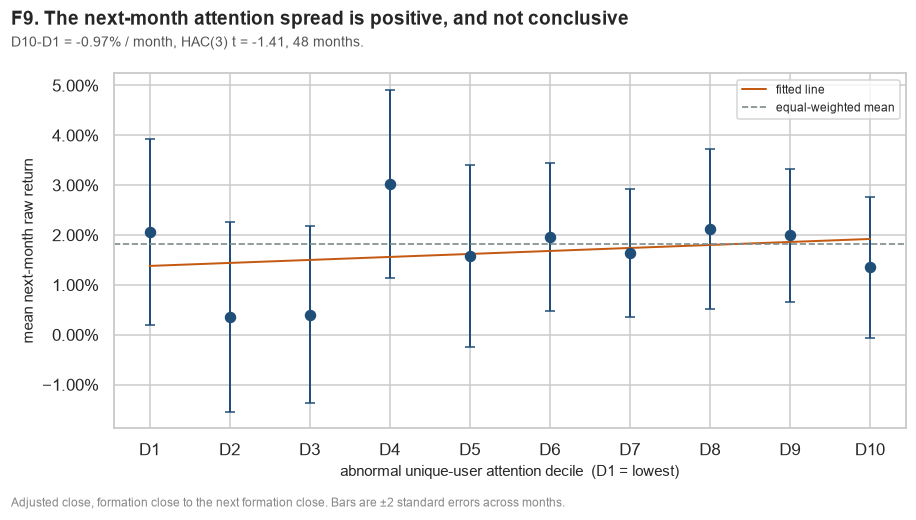

In [ ]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.errorbar(decile_mean.index, decile_mean.values, yerr=2 * decile_se.values, fmt="o",
            color=PALETTE["primary"], ecolor=PALETTE["primary"], elinewidth=1.3,
            capsize=3.5, markersize=6.5)
coef = np.polyfit(decile_mean.index, decile_mean.values, 1)
ax.plot(decile_mean.index, np.polyval(coef, decile_mean.index), color=PALETTE["accent"], linewidth=1.3, label="fitted line")
ax.axhline(port_panel["raw_return"].mean(), color=PALETTE["neutral"], linestyle="--", linewidth=1.1, label="equal-weighted mean")
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"D{i}" for i in range(1, 11)])
ax.set_xlabel("abnormal unique-user attention decile  (D1 = lowest)")
ax.set_ylabel("mean next-month raw return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
ax.legend(loc="best", fontsize=8)
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F9. The next-month attention spread is negative, and not conclusive",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"D10-D1 = {spread.mean():.2%} / month, HAC(3) t = {spread_hac_t:.2f}, {len(spread)} months.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Adjusted close, formation close to the next formation close. Bars are ±2 standard errors across months.",
         fontsize=7.6, color="#888888")
plt.show()


The headline D10−D1 spread is negative (−0.97% per month, HAC t ≈ −1.4) and not significant. The orange fitted line across all ten deciles still slopes slightly up: that line is not the same as D10−D1, middle deciles (especially low D2/D3 and high D4) pull the slope, while the spread only compares the extremes. The pattern across deciles is noisy and non-monotonic, so we do not read a clean attention-return relationship from this figure.

### 4.4 Does attention predict returns?


In [32]:
# Same-month return (overlaps the attention window) and longer holding periods.
same_month = px.pct_change()
held_3m = px.pct_change(3).shift(-3)

horizons = {}
for name, ret_wide in (("contemporaneous", same_month), ("3m", held_3m)):
    long = ret_wide.stack().rename("raw_return").reset_index()
    long.columns = ["form_date", "ticker", "raw_return"]
    long["ticker"] = long["ticker"].astype(str)
    panel = portfolios.merge(long, on=["form_date", "ticker"], how="inner")
    panel = panel.loc[np.isfinite(panel["raw_return"])]
    w = calculate_portfolio_returns(panel, "raw_return").pivot(index="formation_ts", columns="portfolio", values="ret")
    horizons[name] = (w[N_PORTFOLIOS] - w[1]).dropna()
spread_contemp = horizons.pop("contemporaneous")

# One day and one week are trading days on the daily price panel, not calendar days.
idx = price_wide.index
pos = pd.Series(np.arange(len(idx)), index=idx)
col = pd.Series(np.arange(price_wide.shape[1]), index=price_wide.columns)
vals = price_wide.to_numpy()
base = portfolios.dropna(subset=["form_date"]).copy()
base["i0"] = base["form_date"].map(pos)
base["j"] = base["ticker"].map(col)
base = base.dropna(subset=["i0", "j"]).copy()
base["i0"] = base["i0"].astype(int)
base["j"] = base["j"].astype(int)
for name, n_days in (("1d", 1), ("1w", 5)):
    g = base.loc[base["i0"] + n_days < len(idx)].copy()
    p0, p1 = vals[g["i0"], g["j"]], vals[g["i0"] + n_days, g["j"]]
    g["raw_return"] = p1 / p0 - 1
    g = g.loc[np.isfinite(g["raw_return"]) & (p0 != 0)]
    w = calculate_portfolio_returns(g, "raw_return").pivot(index="formation_ts", columns="portfolio", values="ret")
    horizons[name] = (w[N_PORTFOLIOS] - w[1]).dropna()
horizons["1m"] = spread
print(f"Contemporaneous D10−D1: {spread_contemp.mean():+.4%}")
for name, series in horizons.items():
    fit = sm.OLS(series.to_numpy(), np.ones((len(series), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})
    print(f"  {name:<4} mean {series.mean():+.4%}   t_HAC3 {float(fit.tvalues[0]):+.2f}   n {len(series)}")


Contemporaneous D10−D1: +0.1907%
  3m   mean +0.9489%   t_HAC3 +0.59   n 47
  1d   mean +0.4121%   t_HAC3 +1.92   n 49
  1w   mean +0.5581%   t_HAC3 +1.12   n 49
  1m   mean -0.9726%   t_HAC3 -1.41   n 48


The high-attention portfolio (D10) minus the low-attention portfolio (D1):

* Same month: +0.19% —> attention and returns move together in the same period; not a forecast.
* Next day: +0.41% —> small positive gap; the only horizon close to usual significance (t ≈ 1.9).
* Next week: +0.56% —> still positive, but weak (t ≈ 1.1).
* Next month: −0.97% —> the main trading horizon; negative and not significant (t ≈ −1.4).
* Next 3 months: +0.95% total —> looks positive on average, but not significant (t ≈ 0.6).

Bottom line: More StockTwits attention is weakly linked to short-term returns. There is no clear, reliable return difference at the one-month horizon.

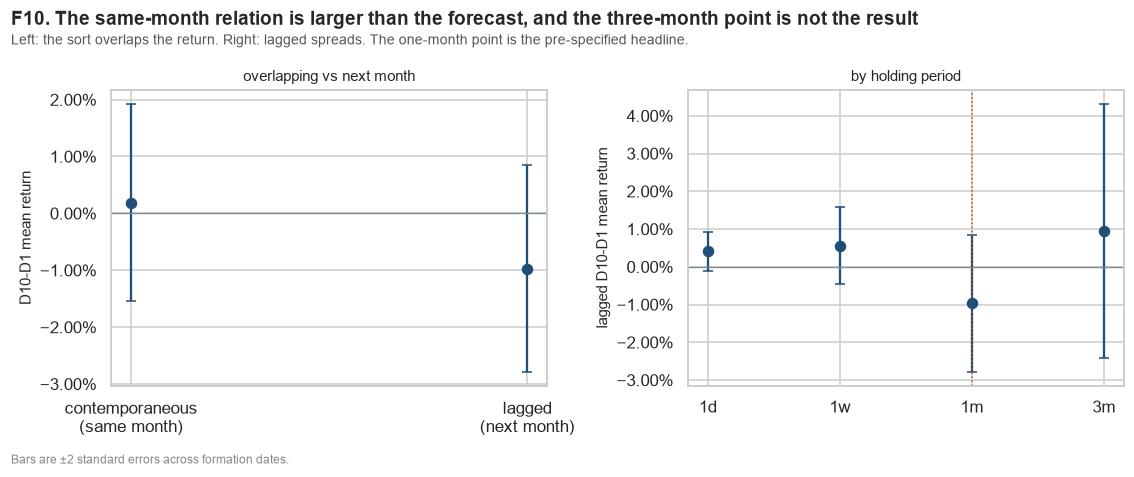

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
ax = axes[0]
means = [spread_contemp.mean(), spread.mean()]
ses = [spread_contemp.sem(), spread.sem()]
ax.errorbar([0, 1], means, yerr=2 * np.array(ses), fmt="o", color=PALETTE["primary"], capsize=3.5, markersize=6.5)
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.9)
ax.set_xticks([0, 1])
ax.set_xticklabels(["contemporaneous\n(same month)", "lagged\n(next month)"])
ax.set_ylabel("D10-D1 mean return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
ax.set_title("overlapping vs next month", fontsize=10)
ax = axes[1]
order = ["1d", "1w", "1m", "3m"]
h_mean = [horizons[k].mean() for k in order]
h_se = [horizons[k].sem() for k in order]
ax.errorbar(range(4), h_mean, yerr=2 * np.array(h_se), fmt="o", color=PALETTE["primary"], capsize=3.5, markersize=6.5)
ax.axhline(0, color=PALETTE["neutral"], linewidth=0.9)
ax.axvline(2, color=PALETTE["accent"], linestyle=":", linewidth=1.0)
ax.set_xticks(range(4))
ax.set_xticklabels(order)
ax.set_ylabel("lagged D10-D1 mean return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
ax.set_title("by holding period", fontsize=10)
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F10. The same-month relation is larger than the forecast, and the three-month point is not the result",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, "Left: the sort overlaps the return. Right: lagged spreads. The one-month point is the pre-specified headline.",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Bars are ±2 standard errors across formation dates.", fontsize=7.6, color="#888888")
plt.show()


Same-month and short horizons (1d/1w) look weakly positive, but that is mostly overlap or noise; the bars still cross zero. The headline next-month spread is negative and insignificant, and the 3m point is not a result either.

### 4.5 Robustness

The same sort with sentiment instead of attention, a weekly version, and a few changes to the window, the baseline and the user floor. The first row of the table is the specification above.


In [34]:
# Robustness checks: try different settings for baseline/user thresholds/window/etc.
specs = [
    ("headline: 30d, K=12, U≥5, users", dict(window_days=30, n_baseline=12, min_users=5, count="users", gap_aware=True)),
    ("baseline K=3", dict(window_days=30, n_baseline=3, min_users=5, count="users", gap_aware=True)),
    ("baseline K=6", dict(window_days=30, n_baseline=6, min_users=5, count="users", gap_aware=True)),
    ("floor U≥3", dict(window_days=30, n_baseline=12, min_users=3, count="users", gap_aware=True)),
    ("floor U≥10", dict(window_days=30, n_baseline=12, min_users=10, count="users", gap_aware=True)),
    ("count = messages", dict(window_days=30, n_baseline=12, min_users=5, count="messages", gap_aware=True)),
    ("no gap-aware baseline", dict(window_days=30, n_baseline=12, min_users=5, count="users", gap_aware=False)),
    ("63-day window", dict(window_days=63, n_baseline=12, min_users=5, count="users", gap_aware=True)),
    ("91-day window", dict(window_days=91, n_baseline=12, min_users=5, count="users", gap_aware=True)),
]
robust_rows = []
for name, spec in specs:
    # Run abnormal attention and calculate decile portfolio spreads
    panel = calculate_abnormal_attention(factor_mentions, formation_monthly, **spec)
    panel["g_att"] = np.log1p(panel["att_window"]) - np.log1p(panel["att_baseline"])
    elig = panel.loc[panel["eligible"]].copy()
    elig["form_date"] = elig["formation_ts"].dt.tz_localize(None).dt.normalize()
    assigned = assign_deciles(elig, "g_att", N_PORTFOLIOS)
    dates = pd.DatetimeIndex(sorted(assigned["form_date"].unique()))
    nxt = price_wide.reindex(dates).pct_change().shift(-1)
    long = nxt.stack().rename("raw_return").reset_index()
    long.columns = ["form_date", "ticker", "raw_return"]
    long["ticker"] = long["ticker"].astype(str)
    joined = assigned.merge(long, on=["form_date", "ticker"], how="inner")
    joined = joined.loc[np.isfinite(joined["raw_return"])]
    w = calculate_portfolio_returns(joined, "raw_return").pivot(index="formation_ts", columns="portfolio", values="ret")
    sp = (w[N_PORTFOLIOS] - w[1]).dropna()
    fit = sm.OLS(sp.to_numpy(), np.ones((len(sp), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})
    robust_rows.append({
        "spec": name,
        "mean_spread": float(sp.mean()),
        "t_HAC3": float(fit.tvalues[0]),
        "n_dates": int(elig["formation_ts"].nunique()),
        "median_n": float(elig.groupby("formation_ts").size().median())
    })
    print(f"{name}: {sp.mean():+.4%}  t={float(fit.tvalues[0]):+.2f}")

robust_table = pd.DataFrame(robust_rows)
print()
print(robust_table.round(4).to_string(index=False))


headline: 30d, K=12, U≥5, users: -0.0084%  t=-0.01
baseline K=3: -0.2003%  t=-0.27
baseline K=6: +0.0310%  t=+0.05
floor U≥3: -0.0084%  t=-0.01
floor U≥10: +0.0401%  t=+0.07
count = messages: -0.3825%  t=-0.59
no gap-aware baseline: +0.0217%  t=+0.04
63-day window: +0.5086%  t=+0.81
91-day window: +0.9883%  t=+1.48

                           spec  mean_spread  t_HAC3  n_dates  median_n
headline: 30d, K=12, U≥5, users      -0.0001 -0.0137       74      21.0
                   baseline K=3      -0.0020 -0.2727       72      21.0
                   baseline K=6       0.0003  0.0498       70      21.0
                      floor U≥3      -0.0001 -0.0137       74      21.0
                     floor U≥10       0.0004  0.0660       74      21.0
               count = messages      -0.0038 -0.5901       74      21.0
          no gap-aware baseline       0.0002  0.0353       74      21.0
                  63-day window       0.0051  0.8079       72      21.0
                  91-day window   

We re-run the same next-month D10−D1 sort under different settings for how we measure attention (shorter or longer baselines, different user floors, messages instead of users, ignoring the 2017 gap, and longer windows). The idea is to check whether the result only appears under one recipe. None of these setups is statistically significant: the mean spreads stay small and the t-stats stay well below conventional cutoffs.

In [35]:
# Sentiment sorts are secondary. Each stock is compared with its own average tone.
# Prefer the windowed sample parquet; otherwise rebuild from scored IDs + month-end windows.
_sample_path = CACHE_DIR / "sentiment_sample.parquet"
if _sample_path.exists():
    sentiment_sample = pd.read_parquet(_sample_path)
else:
    scored_ids = set(sentiment_scores["roberta"]["message_id"])
    ordered = (
        factor_mentions.loc[factor_mentions["message_id"].isin(scored_ids),
                            ["message_id", "ticker", "user", "dt_et"]]
        .sort_values("dt_et", kind="stable", ignore_index=True)
    )
    ts = ordered["dt_et"].values.astype("datetime64[ns]").astype("int64")
    day_ns = 86_400_000_000_000
    parts = []
    for t in formation_monthly:
        lo, hi = np.searchsorted(ts, [int(t.value) - ATT_WINDOW_DAYS * day_ns, int(t.value)], side="right")
        if lo >= hi:
            continue
        chunk = ordered.iloc[lo:hi].copy()
        chunk["formation_ts"] = t
        parts.append(chunk)
    sentiment_sample = pd.concat(parts, ignore_index=True)

# Prefer scores that match the windowed sample; fall back to random / in-memory.
_score = {}
_from_windowed = _sample_path.exists()
for model in ("roberta", "finbert"):
    cands = []
    if _from_windowed:
        cands += [CACHE_DIR / f"scores_{model}.parquet", CACHE_DIR / f"scores_{model}_random.parquet"]
    else:
        cands += [CACHE_DIR / f"scores_{model}_random.parquet", CACHE_DIR / f"scores_{model}.parquet"]
    loaded = None
    for cand in cands:
        if cand.exists():
            loaded = pd.read_parquet(cand)
            break
    if loaded is None and model in sentiment_scores:
        loaded = sentiment_scores[model]
    if loaded is None:
        raise FileNotFoundError(f"No scores file for {model}")
    _score[model] = loaded

sent_rows = []
for model in ("roberta", "finbert"):
    scored = sentiment_sample.merge(
        _score[model][["message_id", "label"]], on="message_id", how="inner")
    vote = (scored.groupby(["formation_ts", "ticker", "user"], observed=True)["label"]
            .agg(lambda s: s.mode().iloc[0] if len(s.mode()) == 1 else np.nan)
            .dropna().rename("vote").reset_index())
    counts = vote.groupby(["formation_ts", "ticker"], observed=True)["vote"].value_counts().unstack(fill_value=0)
    for colname in ("positive", "negative", "neutral"):
        if colname not in counts.columns:
            counts[colname] = 0
    counts = counts.reset_index()
    counts["n_all"] = counts["positive"] + counts["negative"] + counts["neutral"]
    levels = {
        "gNS": np.where(counts["n_all"] > 0, (counts["positive"] - counts["negative"]) / counts["n_all"], np.nan),
        "gPOS": np.log1p(counts["positive"]),
        "gNEG": np.log1p(counts["negative"]),
    }
    for signal_name, level in levels.items():
        frame = counts[["formation_ts", "ticker"]].copy()
        frame["level"] = level
        frame["g_att"] = frame["level"] - frame.groupby("ticker")["level"].transform("mean")
        frame = frame.dropna(subset=["g_att"])
        joined = frame.merge(port_panel[["ticker", "formation_ts", "raw_return"]],
                             on=["ticker", "formation_ts"], how="inner")
        assigned = assign_deciles(joined, "g_att", N_PORTFOLIOS)
        w = calculate_portfolio_returns(assigned, "raw_return").pivot(
            index="formation_ts", columns="portfolio", values="ret")
        sp = (w[N_PORTFOLIOS] - w[1]).dropna()
        fit = sm.OLS(sp.to_numpy(), np.ones((len(sp), 1))).fit(
            cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})
        sent_rows.append({"signal": signal_name, "model": model, "mean_spread": float(sp.mean()),
                          "t_HAC3": float(fit.tvalues[0]), "n_months": len(sp)})
print(f"sentiment_sample rows: {len(sentiment_sample):,}")
print(pd.DataFrame(sent_rows).round(4).to_string(index=False))


sentiment_sample rows: 696,702
signal   model  mean_spread  t_HAC3  n_months
   gNS roberta       0.0080  0.9131        73
  gPOS roberta      -0.0066 -1.2250        73
  gNEG roberta      -0.0042 -0.8092        73
   gNS finbert       0.0051  0.6598        73
  gPOS finbert      -0.0024 -0.3442        73
  gNEG finbert      -0.0019 -0.3531        73


We also sort stocks by tone instead of attention: net sentiment (positive minus negative), positive-only, and negative-only, each relative to that stock’s own average. Same next-month D10−D1 idea, with RoBERTa and FinBERT. Spreads are tiny (about −0.7% to +0.8% per month) and t-stats stay well below 2, so none of these sentiment sorts is statistically significant. Tone does not beat attention here, and attention itself was not a clear signal either.

---

## Task #5 — FF5 adjustment (optional)

We ask whether the +0.50% spread is mostly a size effect, and whether anything is left after the Fama-French five factors. For stocks with at least 24 months we also repeat the sort on the residual from those factors.


In [36]:
import io, zipfile, urllib.request

# Path for cached FF5 factor data
ff_path = CACHE_DIR / "ff5.parquet"

if ff_path.exists():
    # Load cached FF5 data if available
    ff5 = pd.read_parquet(ff_path)
else:
    # Download FF5 data from Ken French's website
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
    with urllib.request.urlopen(url) as resp:
        blob = resp.read()
    # Extract CSV from zip
    with zipfile.ZipFile(io.BytesIO(blob)) as zf:
        text = zf.read(zf.namelist()[0]).decode("utf-8", errors="replace")
    
    # Parse the relevant data portion of the file
    body, started = [], False
    for line in text.splitlines():
        s = line.strip()
        if not started:
            if len(s) >= 7 and s[:6].isdigit() and s[6] == ",":
                started = True
            else:
                continue
        if not s or s.lower().startswith("annual"):
            break
        body.append(s)
    # Read into DataFrame
    ff5 = pd.read_csv(io.StringIO("date,Mkt-RF,SMB,HML,RMW,CMA,RF\n" + "\n".join(body)))
    ff5["date"] = pd.to_datetime(ff5["date"].astype(str), format="%Y%m")
    # Convert columns to floats, scale to decimals
    for colname in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
        ff5[colname] = pd.to_numeric(ff5[colname], errors="coerce") / 100.0
    # Drop rows lacking RF
    ff5 = ff5.dropna(subset=["RF"])
    ff5.to_parquet(ff_path, index=False)

# Add monthly period column for merging
ff5["ret_period"] = ff5["date"].dt.to_period("M")
print(f"FF5 months: {ff5['date'].min().date()} to {ff5['date'].max().date()}")


FF5 months: 1963-07-01 to 2026-08-01


Max |raw spread − excess spread|: 1.39e-17
D10-D1 of FF5 residuals: -0.8039%   t_HAC3 -1.31
                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     3.431
Date:                Fri, 02 Oct 2026   Prob (F-statistic):             0.0109
Time:                        20:29:46   Log-Likelihood:                 68.743
No. Observations:                  48   AIC:                            -125.5
Df Residuals:                      42   BIC:                            -114.3
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

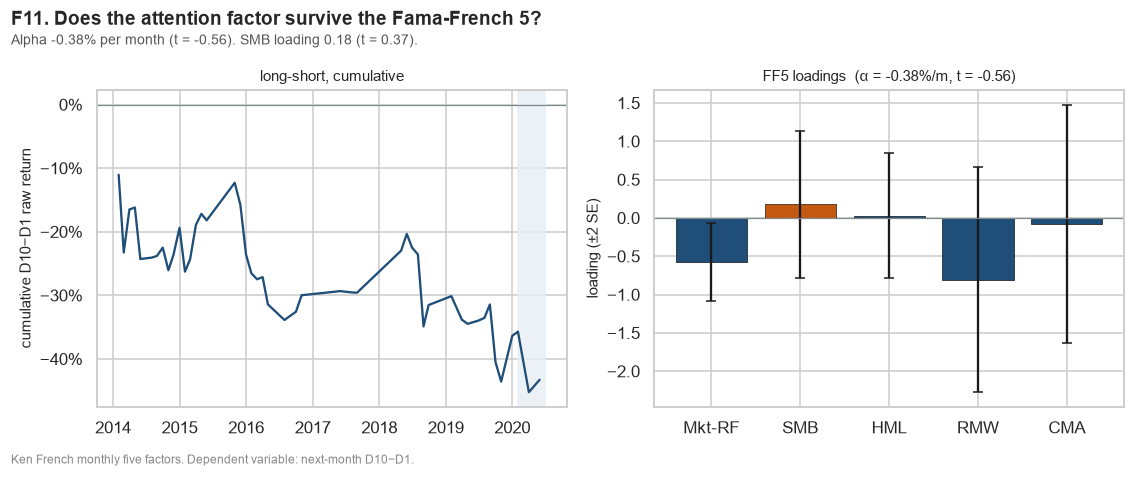

In [37]:
# Calculate holding period: returns measured in the month after formation
hold = (port_panel["form_date"] + pd.offsets.MonthBegin(1)).dt.to_period("M")
stock = port_panel.copy()
stock["ret_period"] = hold

# Merge monthly FF5 factors into our data
stock = stock.merge(ff5.drop(columns="date"), on="ret_period", how="left")

# Compute excess return (return above risk-free rate)
stock["excess_return"] = stock["raw_return"] - stock["RF"]

# Compute D10-D1 spread in excess returns
spread_excess = stock.groupby(["formation_ts", "portfolio"])["excess_return"].mean().unstack()
excess_spread = (spread_excess[N_PORTFOLIOS] - spread_excess[1]).dropna()
print(f"Max |raw spread − excess spread|: {(spread - excess_spread.reindex(spread.index)).abs().max():.2e}")

# Run FF5 regression stock-by-stock and collect residuals (abnormal returns)
resid_rows = []
for ticker, g in stock.dropna(subset=["excess_return", "Mkt-RF"]).groupby("ticker"):
    if len(g) < 24:  # Need minimum 24 months of data
        continue
    X = sm.add_constant(g[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
    fit = sm.OLS(g["excess_return"].to_numpy(), X).fit()
    tmp = g[["formation_ts", "ticker", "portfolio"]].copy()
    tmp["abnormal_return"] = fit.resid
    resid_rows.append(tmp)
resid = pd.concat(resid_rows, ignore_index=True)

# Compute D10-D1 spread in abnormal returns
w = calculate_portfolio_returns(resid, "abnormal_return").pivot(index="formation_ts", columns="portfolio", values="ret")
spread_abn = (w[N_PORTFOLIOS] - w[1]).dropna()
fit_abn = sm.OLS(spread_abn.to_numpy(), np.ones((len(spread_abn), 1))).fit(
    cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})
print(f"D10-D1 of FF5 residuals: {spread_abn.mean():+.4%}   t_HAC3 {float(fit_abn.tvalues[0]):+.2f}")

# Fama-French 5 regression on D10-D1 spread itself
y = spread.dropna()
reg = pd.DataFrame({
    "spread": y.to_numpy(),
    "ret_period": (y.index.tz_localize(None) + pd.DateOffset(months=1)).to_period("M")
})
reg = reg.merge(ff5.drop(columns="date"), on="ret_period", how="inner")
ff_model = sm.OLS(reg["spread"], sm.add_constant(reg[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 3, "use_correction": True})

# Get regression stats
alpha = float(ff_model.params["const"])
alpha_t = float(ff_model.tvalues["const"])
smb = float(ff_model.params["SMB"])
smb_t = float(ff_model.tvalues["SMB"])

print(ff_model.summary())
print(f"Alpha {alpha:.4%} per month, t = {alpha_t:.2f}")
print(f"SMB {smb:.3f}, t = {smb_t:.2f}")

# Plot cumulative D10-D1 return and FF5 loadings
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
cum = (1 + spread.sort_index()).cumprod() - 1
axes[0].plot(cum.index.tz_localize(None), cum.values, color=PALETTE["primary"])
axes[0].axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"), color=PALETTE["shade"], alpha=0.8)
axes[0].axhline(0, color=PALETTE["neutral"], linewidth=0.8)
axes[0].set_ylabel("cumulative D10−D1 raw return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
axes[0].set_title("long-short, cumulative", fontsize=10)
load = ff_model.params.drop("const")
se = ff_model.bse.drop("const")
axes[1].bar(load.index, load.values, yerr=2 * se.values,
            color=["#C45911" if name == "SMB" else PALETTE["primary"] for name in load.index],
            edgecolor="black", linewidth=0.4, capsize=3)
axes[1].axhline(0, color=PALETTE["neutral"], linewidth=0.8)
axes[1].set_ylabel("loading (±2 SE)")
axes[1].set_title(f"FF5 loadings  (α = {alpha:.2%}/m, t = {alpha_t:.2f})", fontsize=10)
fig.tight_layout(rect=(0, 0.02, 1, 0.90))
fig.text(0.01, 0.985, "F11. Does the attention factor survive the Fama-French 5?",
         fontsize=12.5, fontweight="bold", ha="left", va="top")
fig.text(0.01, 0.935, f"Alpha {alpha:.2%} per month (t = {alpha_t:.2f}). SMB loading {smb:.2f} (t = {smb_t:.2f}).",
         fontsize=9.2, color="#555555", ha="left", va="top")
fig.text(0.01, 0.005, "Ken French monthly five factors. Dependent variable: next-month D10−D1.",
         fontsize=7.6, color="#888888")
plt.show()


**Attention does not look like a reliable priced factor once we adjust for standard risk factor**

Explaination of symbols:
| Factor | Full name | Meaning |
|--------|-----------|---------|
| **Mkt-RF** | Market excess return | Market return minus the risk-free rate |
| **SMB** | Small Minus Big | Small stocks minus big stocks (size) |
| **HML** | High Minus Low | High book-to-market minus low (value vs growth) |
| **RMW** | Robust Minus Weak | High operating profitability minus low |
| **CMA** | Conservative Minus Aggressive | Low-investment firms minus high-investment firms |
| **RF** | Risk-free rate | Used to form excess returns (r − RF); cancels in a long−short spread |

We regress the next-month D10−D1 attention spread on the Fama–French five factors. Subtracting the risk-free rate does not change the spread much. After we control for the Fama–French five factors, the leftover return (alpha) is about −0.38% per month and not statistically significant. So there is no clear attention premium.  
The size factor (SMB) is also small, so this is not simply a small-stock portfolio. The only notable result is that the spread moves against the market when the market is up (negative market loading). The other factor loadings are weak.  
When we sort on returns after removing FF5 effects stock by stock, the spread is still about −0.80% and again not significant.